# Comparativa de Experimentos Non-IID
Lee todos los `*_Mean_global.csv` y genera tablas y gráficas comparativas.

In [11]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

BASE = Path('.')

# ===========================================================
# Registro de experimentos: (escenario, param, path_glob)
# ===========================================================
EXPERIMENTS = [
    # (escenario,               param,    carpeta)
    ('IID Balanced',            'IID',    BASE / 'balanced/experimentos_balanced'),
    ('Gaussian Affine',         'σ=0.05', BASE / 'attribute_skew/gaussian_affine/experimentos_GaussianAffine_0.05'),
    ('Gaussian Affine',         'σ=0.3',  BASE / 'attribute_skew/gaussian_affine/experimentos_GaussianAffine_0.3'),
    ('Dirichlet (label skew)',  'α=0.8',  BASE / 'label_skew/Distribution-Based/experimentos_DirichletPartioner_0.8'),
    ('Dirichlet (label skew)',  'α=0.7',  BASE / 'label_skew/Distribution-Based/experimentos_DirichletPartioner_0.7'),
    ('Size Imbalance',          'α=0.5',  BASE / 'size_imbalance/experimentos_size_imbalanced_0.5'),
    ('Size Imbalance',          'α=1.0',  BASE / 'size_imbalance/experimentos_size_imbalanced_1.0'),
]

# ===========================================================
# Cargar todos los CSVs
# ===========================================================
records = []
for escenario, param, folder in EXPERIMENTS:
    for csv_path in sorted(folder.glob('**/*_Clients_Mean_global.csv')):
        dataset   = csv_path.parent.name
        n_clients = int(csv_path.stem.split('_')[0])
        df = pd.read_csv(csv_path).set_index('metric')['mean']
        row = {'escenario': escenario, 'param': param,
               'dataset': dataset, 'n_clients': n_clients}
        row.update(df.to_dict())
        records.append(row)

df_all = pd.DataFrame(records)
df_all['label'] = df_all['escenario'] + ' ' + df_all['param']

# ===========================================================
# Paleta de colores por escenario
# ===========================================================
COLORS = {
    'IID Balanced IID':              '#4CAF50',
    'Gaussian Affine σ=0.05':        '#2196F3',
    'Gaussian Affine σ=0.3':         '#0D47A1',
    'Dirichlet (label skew) α=0.8':  '#FF9800',
    'Dirichlet (label skew) α=0.7':  '#E65100',
    'Size Imbalance α=0.5':          '#9C27B0',
    'Size Imbalance α=1.0':          '#4A148C',
}

print(f'Experimentos cargados: {len(df_all)}')
print(df_all[['escenario','param','dataset','n_clients']].to_string(index=False))

Experimentos cargados: 42
             escenario  param      dataset  n_clients
          IID Balanced    IID breastcancer          4
          IID Balanced    IID breastcancer          6
          IID Balanced    IID breastcancer          8
          IID Balanced    IID     Diabetes          4
          IID Balanced    IID     Diabetes          6
          IID Balanced    IID     Diabetes          8
       Gaussian Affine σ=0.05 breastcancer          4
       Gaussian Affine σ=0.05 breastcancer          6
       Gaussian Affine σ=0.05 breastcancer          8
       Gaussian Affine σ=0.05     Diabetes          4
       Gaussian Affine σ=0.05     Diabetes          6
       Gaussian Affine σ=0.05     Diabetes          8
       Gaussian Affine  σ=0.3 breastcancer          4
       Gaussian Affine  σ=0.3 breastcancer          6
       Gaussian Affine  σ=0.3 breastcancer          8
       Gaussian Affine  σ=0.3     Diabetes          4
       Gaussian Affine  σ=0.3     Diabetes          6
  

In [12]:
# ===========================================================
# Métricas clave para la comparativa
# ===========================================================
METRICS = {
    # Q1 — Consistencia LORE
    'jaccard_lore_struct':               'Jaccard Struct. LORE',
    'sim_aditiva_lore':                  'Sim. Aditiva LORE',
    'jaccard_cov_localZ_LORE':           'Jaccard Cov. LORE (localZ)',
    'jaccard_cov_globalZ_LORE':          'Jaccard Cov. LORE (globalZ)',
    'jaccard_cov_combinedZ_LORE':        'Jaccard Cov. LORE (combinedZ)',
    'cov_ruleLocal_on_localZ_LORE':      'Cov. Regla Local → Z_local',
    'cov_ruleGlobal_on_localZ_LORE':     'Cov. Regla Global → Z_local',
    'cov_ruleLocal_on_globalZ_LORE':     'Cov. Regla Local → Z_global',
    'cov_ruleGlobal_on_globalZ_LORE':    'Cov. Regla Global → Z_global',
    'covInter_localZ_LORE':              'Cov. Intersección LORE (localZ)',
    'covInter_globalZ_LORE':             'Cov. Intersección LORE (globalZ)',
    'covInter_combinedZ_LORE':           'Cov. Intersección LORE (combinedZ)',
    'covUnion_localZ_LORE':              'Cov. Unión LORE (localZ)',
    'covUnion_globalZ_LORE':             'Cov. Unión LORE (globalZ)',
    'covUnion_combinedZ_LORE':           'Cov. Unión LORE (combinedZ)',
    'has_factual_local':                 'Tiene factual LORE (local)',
    'has_factual_global':                'Tiene factual LORE (global)',
    'ratio_has_factual_localZ_LORE':     'Ratio factual LORE (localZ)',
    'ratio_has_factual_globalZ_LORE':    'Ratio factual LORE (globalZ)',
    'ratio_has_factual_combinedZ_LORE':  'Ratio factual LORE (combinedZ)',
    # Q1 — Consistencia Anchor
    'jaccard_anchor_struct_testglobal':  'Jaccard Struct. Anchor (global test)',
    'jaccard_anchor_struct_testlocal':   'Jaccard Struct. Anchor (local test)',
    'sim_aditiva_anchor_testglobal':     'Sim. Aditiva Anchor (global test)',
    'sim_aditiva_anchor_testlocal':      'Sim. Aditiva Anchor (local test)',
    'anchor_prec_testglobal_local':      'Anchor Prec. Local (global test)',
    'anchor_prec_testglobal_global':     'Anchor Prec. Global (global test)',
    'anchor_prec_testlocal_local':       'Anchor Prec. Local (local test)',
    'anchor_prec_testlocal_global':      'Anchor Prec. Global (local test)',
    'anchor_cov_testglobal_local':       'Anchor Cov. Local (global test)',
    'anchor_cov_testglobal_global':      'Anchor Cov. Global (global test)',
    'anchor_cov_testlocal_local':        'Anchor Cov. Local (local test)',
    'anchor_cov_testlocal_global':       'Anchor Cov. Global (local test)',
    'ratio_has_anchor_testlocal_local':  'Ratio anchor local (local test)',
    'ratio_has_anchor_testlocal_global': 'Ratio anchor global (local test)',
    'ratio_has_anchor_testglobal_local': 'Ratio anchor local (global test)',
    'ratio_has_anchor_testglobal_global':'Ratio anchor global (global test)',
    # Q1 — Consistencia SHAP / LIME
    'delta_shap_testglobal':             'Δ SHAP (global test)',
    'delta_shap_testlocal':              'Δ SHAP (local test)',
    'delta_lime_testglobal':             'Δ LIME (global test)',
    'delta_lime_testlocal':              'Δ LIME (local test)',
    'pred_agreement_globalTest':         'Pred. Agreement (global test)',
    'pred_agreement_localTest':          'Pred. Agreement (local test)',
    # Q2 — Robustez / estabilidad
    'stability_shap_global':             'Estabilidad SHAP (global)',
    'stability_shap_local':              'Estabilidad SHAP (local)',
    'stability_lime_global':             'Estabilidad LIME (global)',
    'stability_lime_local':              'Estabilidad LIME (local)',
    'stability_anchor_testlocal_global': 'Estabilidad Anchor (global)',
    'stability_anchor_testlocal_local':  'Estabilidad Anchor (local)',
    'stability_lore_global':             'Estabilidad LORE (global)',
    'stability_lore_local':              'Estabilidad LORE (local)',
    'tree_fidelity_lore_global':         'Fidelidad Árbol LORE (global)',
    'tree_fidelity_lore_local':          'Fidelidad Árbol LORE (local)',
    'silhouette_global_LORE':            'Silhouette LORE (global)',
    'silhouette_local_LORE':             'Silhouette LORE (local)',
    # Rendimiento
    'acc_localTree_globalTest':          'Acc. Local Tree (global test)',
    'acc_localTree_localTest':           'Acc. Local Tree (local test)',
    'acc_nn_global_globalTest':          'Acc. NN Global (global test)',
    'acc_nn_global_localTest':           'Acc. NN Global (local test)',
    'acc_nn_local_globalTest':           'Acc. NN Local (global test)',
    'acc_nn_local_localTest':            'Acc. NN Local (local test)',
}

disponibles = [k for k in METRICS if k in df_all.columns]
faltantes   = [k for k in METRICS if k not in df_all.columns]
print(f"Métricas disponibles: {len(disponibles)}/{len(METRICS)}")
if faltantes:
    print(f"No encontradas en los CSVs: {faltantes}")

# ===========================================================
# TABLA RESUMEN — media sobre n_clients, por dataset
# ===========================================================
for dataset in sorted(df_all['dataset'].unique()):
    print(f'\n{"="*80}')
    print(f'  DATASET: {dataset}')
    print(f'{"="*80}')
    sub = df_all[df_all['dataset'] == dataset]
    cols = [c for c in METRICS if c in sub.columns]
    tabla = (
        sub.groupby('label')[cols]
           .mean()
           .rename(columns=METRICS)
    )
    order = ['IID Balanced IID',
             'Gaussian Affine σ=0.05', 'Gaussian Affine σ=0.3',
             'Dirichlet (label skew) α=0.8', 'Dirichlet (label skew) α=0.7',
             'Size Imbalance α=0.5', 'Size Imbalance α=1.0']
    tabla = tabla.reindex([o for o in order if o in tabla.index])
    with pd.option_context('display.max_columns', None, 'display.width', 200,
                           'display.float_format', '{:.3f}'.format):
        print(tabla.T.to_string())


Métricas disponibles: 60/60

  DATASET: Diabetes
label                                 IID Balanced IID  Gaussian Affine σ=0.05  Gaussian Affine σ=0.3  Dirichlet (label skew) α=0.8  Dirichlet (label skew) α=0.7  Size Imbalance α=0.5  Size Imbalance α=1.0
Jaccard Struct. LORE                             0.360                   0.308                  0.282                         0.393                         0.367                 0.386                 0.361
Sim. Aditiva LORE                                0.658                   0.623                  0.605                         0.657                         0.651                 0.664                 0.651
Jaccard Cov. LORE (localZ)                       0.716                   0.686                  0.742                         0.649                         0.632                 0.712                 0.710
Jaccard Cov. LORE (globalZ)                      0.765                   0.756                  0.765                         0

# Métricas principales

## pred_agreement

Cuánto coinciden las predicciones del black-box local y del black-box global.

  P1: ACUERDO DE PREDICCIÓN LOCAL vs GLOBAL
  (media sobre 4/6/8 clientes)

  Diabetes
                              Global Test  Local Test  Diff (G-L)
label                                                            
IID Balanced IID                    0.868       0.843       0.025
Gaussian Affine σ=0.05              0.840       0.843      -0.003
Gaussian Affine σ=0.3               0.871       0.864       0.006
Dirichlet (label skew) α=0.8        0.743       0.711       0.032
Dirichlet (label skew) α=0.7        0.733       0.695       0.039
Size Imbalance α=0.5                0.866       0.837       0.028
Size Imbalance α=1.0                0.850       0.832       0.018

  breastcancer
                              Global Test  Local Test  Diff (G-L)
label                                                            
IID Balanced IID                    0.971       0.957       0.014
Gaussian Affine σ=0.05              0.716       0.749      -0.033
Gaussian Affine σ=0.3               0.4

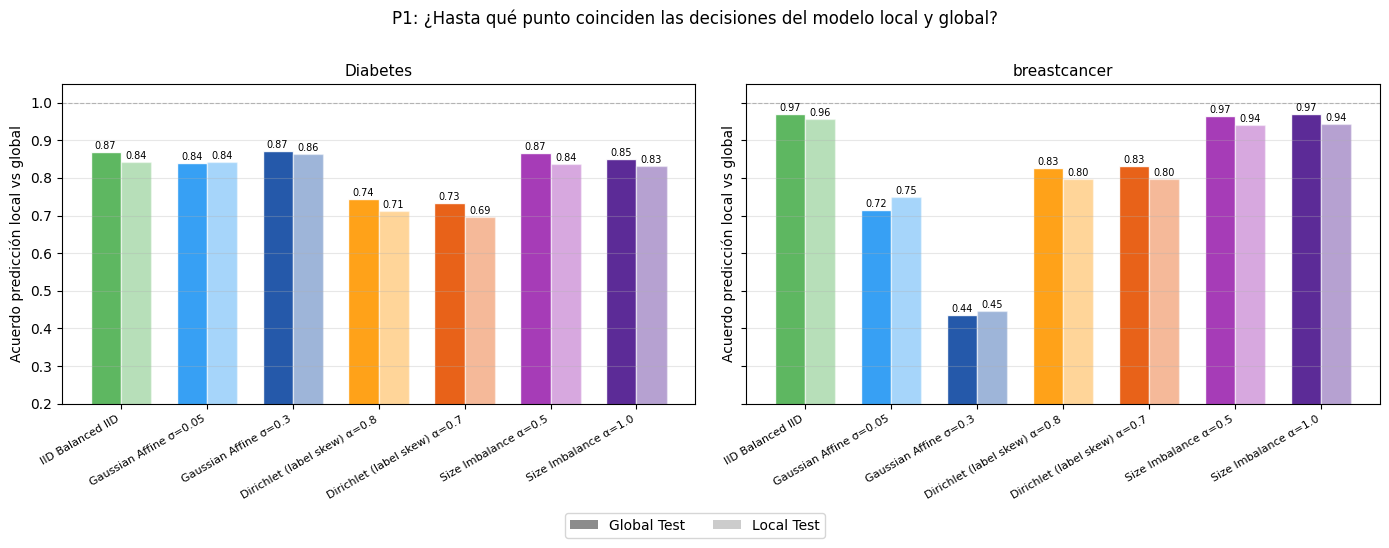

In [13]:

# ===========================================================
# P1: ¿Hasta qué punto el modelo local y el global
#     toman decisiones parecidas?
# Métrica: pred_agreement_globalTest / localTest
# ===========================================================

ORDER = [
    'IID Balanced IID',
    'Gaussian Affine σ=0.05',
    'Gaussian Affine σ=0.3',
    'Dirichlet (label skew) α=0.8',
    'Dirichlet (label skew) α=0.7',
    'Size Imbalance α=0.5',
    'Size Imbalance α=1.0',
]

datasets = sorted(df_all['dataset'].unique())

# ── Tabla ──────────────────────────────────────────────────
print("=" * 70)
print("  P1: ACUERDO DE PREDICCIÓN LOCAL vs GLOBAL")
print("  (media sobre 4/6/8 clientes)")
print("=" * 70)
for dataset in datasets:
    sub   = df_all[df_all['dataset'] == dataset]
    tabla = (
        sub.groupby('label')[['pred_agreement_globalTest', 'pred_agreement_localTest']]
           .mean()
           .rename(columns={'pred_agreement_globalTest': 'Global Test',
                            'pred_agreement_localTest':  'Local Test'})
    )
    tabla = tabla.reindex([o for o in ORDER if o in tabla.index])
    tabla['Diff (G-L)'] = tabla['Global Test'] - tabla['Local Test']
    print(f"\n  {dataset}")
    print(tabla.to_string(float_format='{:.3f}'.format))

# ── Gráfica ────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(datasets), figsize=(7 * len(datasets), 5), sharey=True)
if len(datasets) == 1:
    axes = [axes]

for ax, dataset in zip(axes, datasets):
    sub   = df_all[df_all['dataset'] == dataset]
    tabla = (
        sub.groupby('label')[['pred_agreement_globalTest', 'pred_agreement_localTest']]
           .mean()
           .reindex([o for o in ORDER if o in sub['label'].unique()])
    )
    x      = np.arange(len(tabla))
    width  = 0.35
    colors = [COLORS.get(l, '#aaa') for l in tabla.index]

    bars_g = ax.bar(x - width/2, tabla['pred_agreement_globalTest'],
                    width, color=colors, alpha=0.9, edgecolor='white')
    bars_l = ax.bar(x + width/2, tabla['pred_agreement_localTest'],
                    width, color=colors, alpha=0.4, edgecolor='white')

    ax.set_xticks(x)
    ax.set_xticklabels(tabla.index, rotation=30, ha='right', fontsize=8)
    ax.set_ylim(0.2, 1.05)
    ax.set_title(dataset, fontsize=11)
    ax.set_ylabel('Acuerdo predicción local vs global')
    ax.axhline(1.0, color='grey', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.grid(axis='y', alpha=0.3)

    for bar in list(bars_g) + list(bars_l):
        h = bar.get_height()
        if not np.isnan(h):
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.003,
                    f'{h:.2f}', ha='center', va='bottom', fontsize=7)

from matplotlib.patches import Patch
legend_els = [Patch(facecolor='grey', alpha=0.9, label='Global Test'),
              Patch(facecolor='grey', alpha=0.4,  label='Local Test')]
fig.legend(handles=legend_els, loc='lower center', ncol=2,
           bbox_to_anchor=(0.5, -0.06), fontsize=10)

plt.suptitle('P1: ¿Hasta qué punto coinciden las decisiones del modelo local y global?',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()


**¿Hasta qué punto coinciden las predicciones de bb_local y bb_global?**

En general sí coinciden — excepto cuando el attribute skew es fuerte y el dataset tiene muchas features numéricas (BreastCancer + Gaussian σ=0.3).

- **Diabetes:** acuerdo alto en todos los escenarios. El mínimo es 0.733 (Dirichlet α=0.7) — en 3 de cada 4 instancias bb_local y bb_global predicen lo mismo, incluso con heterogeneidad severa.

- **BreastCancer:**
  - IID y Size Imbalance: acuerdo muy alto (~0.97).
  - Dirichlet: acuerdo moderado (~0.83) — el label skew hace que bb_local se especialice en una distribución de clases distinta a la del bb_global.
  - Gaussian σ=0.3: acuerdo de 0.436 — en más de la mitad de las instancias los modelos predicen cosas distintas. El ruido gaussiano distorsiona tanto el espacio de features del cliente que bb_local aprende una función de decisión fundamentalmente diferente a la del bb_global.

## Métricas de rendimiento del modelo

  RENDIMIENTO DEL MODELO  (media sobre 4/6/8 clientes)

  Diabetes
                              NN_local / test=local  NN_global / test=local  NN_local / test=global  NN_global / test=global  Δ NN (G-L) local  Δ NN (G-L) global
label                                                                                                                                                            
IID Balanced IID                              0.714                   0.732                   0.770                    0.764             0.018             -0.006
Gaussian Affine σ=0.05                        0.721                   0.714                   0.761                    0.761            -0.007              0.000
Gaussian Affine σ=0.3                         0.621                   0.636                   0.647                    0.652             0.014              0.005
Dirichlet (label skew) α=0.8                  0.793                   0.671                   0.720                    0.70

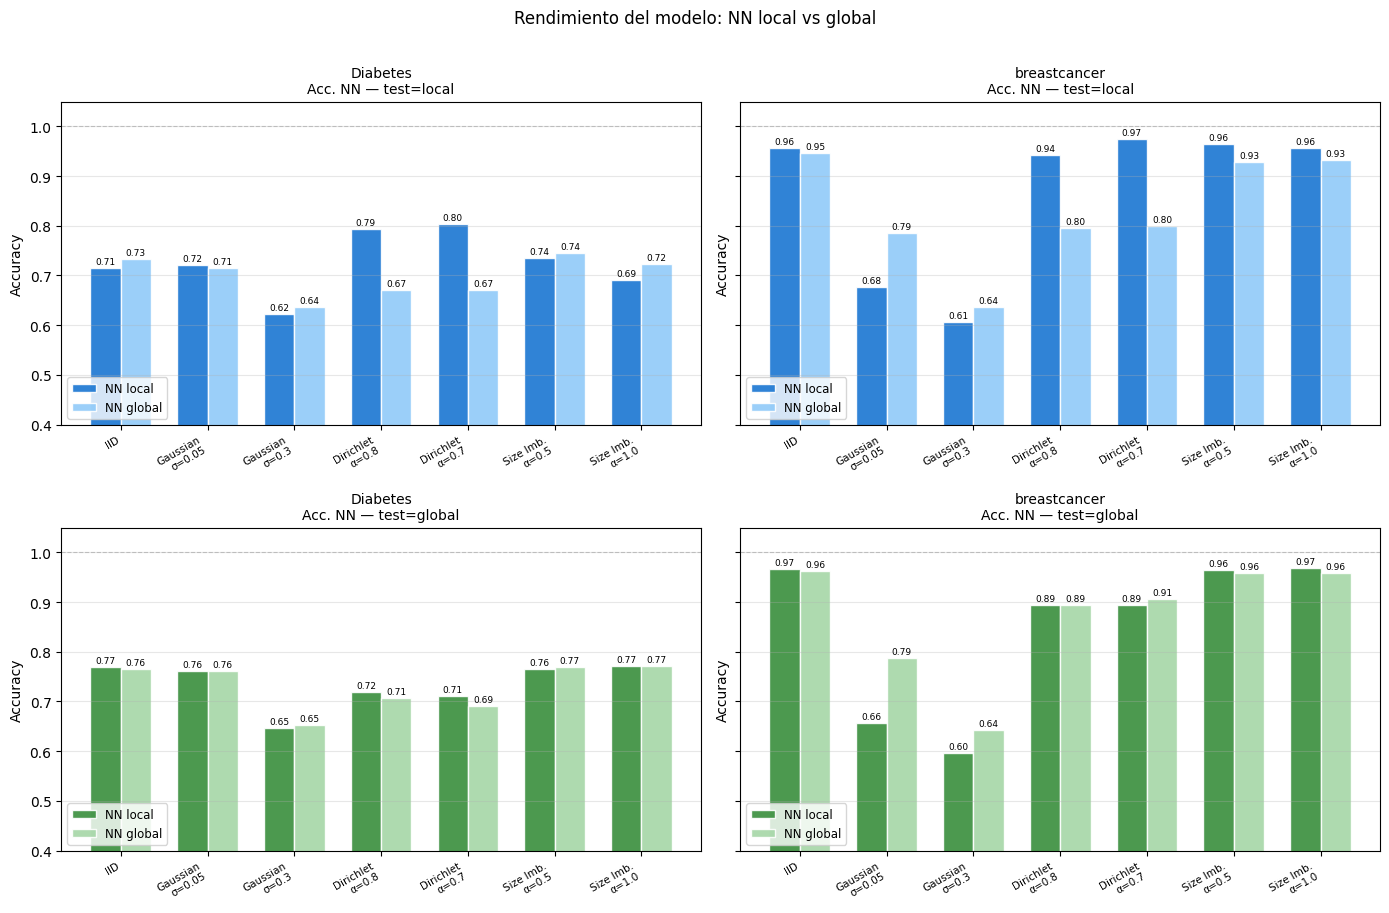

In [14]:
# ===========================================================
# Rendimiento del modelo: NN local vs global
#
# acc_nn_local_*  → precisión del black-box local (modelo del cliente)
# acc_nn_global_* → precisión del black-box global (modelo federado)
#
# Comparación _localTest:  rendimiento en los datos del cliente
# Comparación _globalTest: rendimiento en la distribución global
# ===========================================================

ORDER = [
    'IID Balanced IID',
    'Gaussian Affine σ=0.05',
    'Gaussian Affine σ=0.3',
    'Dirichlet (label skew) α=0.8',
    'Dirichlet (label skew) α=0.7',
    'Size Imbalance α=0.5',
    'Size Imbalance α=1.0',
]

ACC_KEYS = [
    'acc_nn_local_localTest',  'acc_nn_global_localTest',
    'acc_nn_local_globalTest', 'acc_nn_global_globalTest',
]

datasets = sorted(df_all['dataset'].unique())

# ── Tabla ──────────────────────────────────────────────────────────
print("=" * 80)
print("  RENDIMIENTO DEL MODELO  (media sobre 4/6/8 clientes)")
print("=" * 80)
for dataset in datasets:
    sub   = df_all[df_all['dataset'] == dataset]
    keys  = [k for k in ACC_KEYS if k in sub.columns]
    tabla = (
        sub.groupby('label')[keys].mean()
           .reindex([o for o in ORDER if o in sub['label'].unique()])
           .rename(columns={
               'acc_nn_local_localTest':   'NN_local / test=local',
               'acc_nn_global_localTest':  'NN_global / test=local',
               'acc_nn_local_globalTest':  'NN_local / test=global',
               'acc_nn_global_globalTest': 'NN_global / test=global',
           })
    )
    tabla['Δ NN (G-L) local']  = tabla['NN_global / test=local']  - tabla['NN_local / test=local']
    tabla['Δ NN (G-L) global'] = tabla['NN_global / test=global'] - tabla['NN_local / test=global']
    print(f"\n  {dataset}")
    print(tabla.to_string(float_format='{:.3f}'.format))

# ── Gráfica: 2 filas × n_datasets ─────────────────
#   Fila 1: NN local vs global, test=local
#   Fila 2: NN local vs global, test=global
short_labels = lambda lst: [
    o.replace('Dirichlet (label skew) ', 'Dirichlet\n')
     .replace('Gaussian Affine ', 'Gaussian\n')
     .replace('Size Imbalance ', 'Size Imb.\n')
     .replace('IID Balanced ', '') for o in lst
]

rows_cfg = [
    (['acc_nn_local_localTest',  'acc_nn_global_localTest'],
     ['#1976D2', '#90CAF9'], ['NN local', 'NN global'],
     'Acc. NN — test=local'),
    (['acc_nn_local_globalTest', 'acc_nn_global_globalTest'],
     ['#388E3C', '#A5D6A7'], ['NN local', 'NN global'],
     'Acc. NN — test=global'),
]

fig, axes = plt.subplots(2, len(datasets), figsize=(7 * len(datasets), 9), sharey='row')

for row_idx, (keys, colors, labels, row_title) in enumerate(rows_cfg):
    avail = [k for k in keys if k in df_all.columns]
    for col_idx, dataset in enumerate(datasets):
        ax    = axes[row_idx, col_idx]
        sub   = df_all[df_all['dataset'] == dataset]
        orden = [o for o in ORDER if o in sub['label'].unique()]
        t     = sub.groupby('label')[avail].mean().reindex(orden)

        x     = np.arange(len(t))
        width = 0.35

        bars0 = ax.bar(x - width/2, t[avail[0]], width,
                       color=colors[0], alpha=0.9, edgecolor='white', label=labels[0])
        bars1 = ax.bar(x + width/2, t[avail[1]], width,
                       color=colors[1], alpha=0.9, edgecolor='white', label=labels[1])

        ax.set_xticks(x)
        ax.set_xticklabels(short_labels(orden), rotation=30, ha='right', fontsize=7.5)
        ax.set_ylim(0.4, 1.05)
        ax.set_title(f'{dataset}\n{row_title}', fontsize=10)
        ax.set_ylabel('Accuracy')
        ax.axhline(1.0, color='grey', linestyle='--', linewidth=0.8, alpha=0.4)
        ax.grid(axis='y', alpha=0.3)
        ax.legend(fontsize=8.5, loc='lower left')

        for bar in list(bars0) + list(bars1):
            h = bar.get_height()
            if not np.isnan(h):
                ax.text(bar.get_x() + bar.get_width()/2, h + 0.004,
                        f'{h:.2f}', ha='center', va='bottom', fontsize=6.5)

plt.suptitle('Rendimiento del modelo: NN local vs global',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()


**¿Qué rendimiento tienen los modelos según el escenario?**

**IID y Size Imbalance** — ambos modelos rinden de forma comparable en test local y global. Diabetes se mueve entre 0.692 y 0.744; BreastCancer entre 0.928 y 0.968. Las diferencias entre bb_local y bb_global son menores de 0.04 en ambos tests. Los clientes comparten la misma distribución de features y clases, por lo que la agregación federada no introduce ni elimina información relevante.

**Gaussian σ=0.3** — rendimiento bajo en todos los modelos y ambos datasets. En Diabetes los NNs caen a 0.621–0.652; en BreastCancer a 0.597–0.642. El ruido gaussiano corrompe los valores de las features de entrenamiento: ambos modelos aprenden sobre un espacio distorsionado que no refleja la distribución real. El global promedia ruidos de distintos clientes y recupera algo, pero no lo suficiente para compensar la magnitud del ruido.

**Gaussian σ=0.05** — en Diabetes los cuatro valores son similares (0.714–0.761). En BreastCancer aparece una asimetría marcada: bb_local en test local es 0.677 mientras bb_global en test local es 0.786. En test global ambos convergen a 0.657 y 0.786. El modelo local aprende una frontera adaptada a su realización particular del ruido, que no generaliza bien al test. El global, al agregar gradientes de múltiples clientes con ruidos independientes, promedia y cancela parte de las distorsiones.

**Dirichlet** — bb_local en test local da valores altos (0.793–0.804 Diabetes, 0.943–0.974 BreastCancer), pero bb_global en ese mismo test local es considerablemente más bajo (0.671 Diabetes, 0.796–0.800 BreastCancer). En test global la brecha se reduce: en Diabetes bb_local/global es 0.710–0.720 y bb_global/global es 0.692–0.707; en BreastCancer ambos llegan a 0.894–0.906. El label skew hace que el modelo local se especialice en la distribución de clases sesgada de su cliente y rinda bien en su propio test. El bb_global, entrenado sobre la distribución agregada de todos los clientes, no está especializado en ese sesgo — lo que explica su menor accuracy en test=local. Cuando se evalúa en test=global (distribución equilibrada), bb_local y bb_global convergen a valores similares.

# LORE

## Solapamiento entre reglas LORE

jaccard_cov_localZ / globalZ / combinedZ _LORE


  LORE: JACCARD COBERTURA  (media sobre 4/6/8 clientes)

  Diabetes
                              localZ  globalZ  combinedZ
label                                                   
IID Balanced IID               0.716    0.765      0.721
Gaussian Affine σ=0.05         0.686    0.756      0.699
Gaussian Affine σ=0.3          0.742    0.765      0.731
Dirichlet (label skew) α=0.8   0.649    0.708      0.653
Dirichlet (label skew) α=0.7   0.632    0.705      0.640
Size Imbalance α=0.5           0.712    0.767      0.717
Size Imbalance α=1.0           0.710    0.770      0.719

  breastcancer
                              localZ  globalZ  combinedZ
label                                                   
IID Balanced IID               0.691    0.708      0.684
Gaussian Affine σ=0.05         0.672    0.697      0.667
Gaussian Affine σ=0.3          0.613    0.681      0.625
Dirichlet (label skew) α=0.8   0.652    0.626      0.621
Dirichlet (label skew) α=0.7   0.629    0.611      0.602
Siz

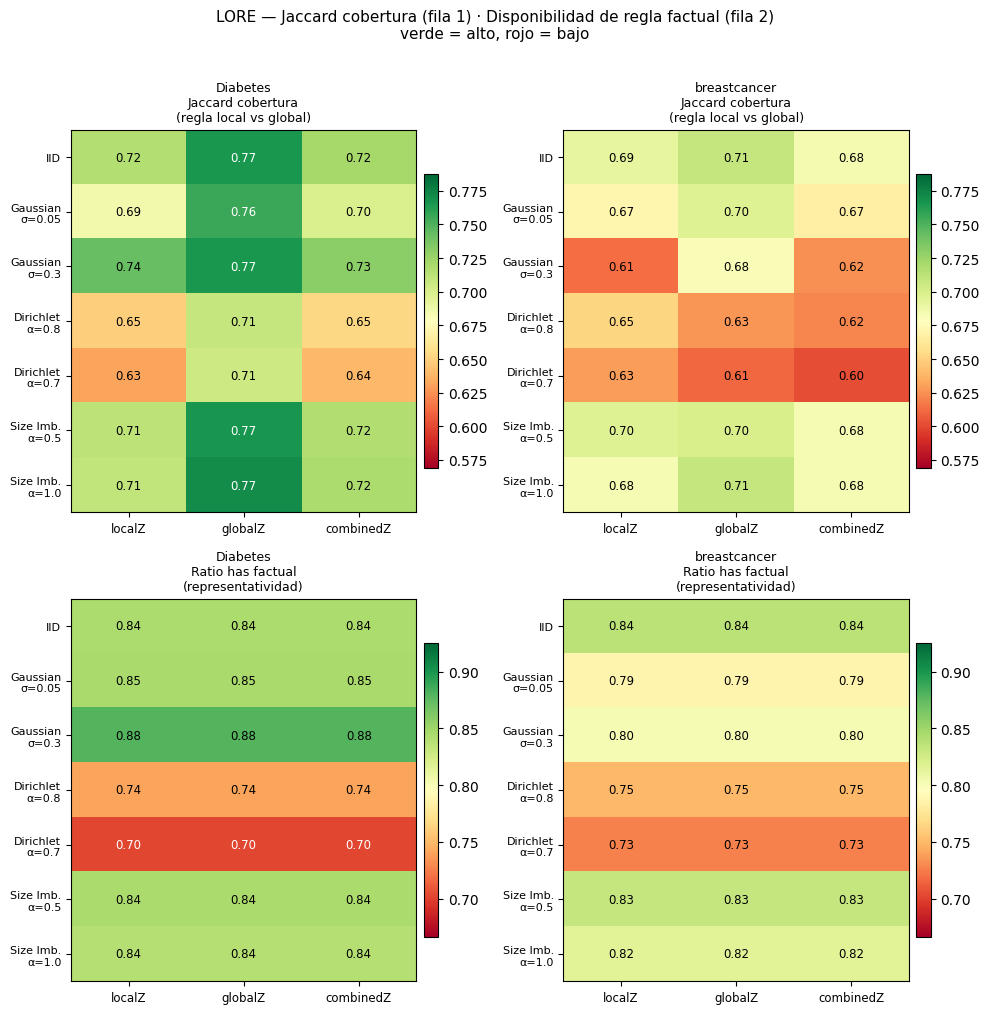

In [15]:

# ===========================================================
# P2: Jaccard de cobertura + ratio_has_factual de LORE
#
# jaccard_cov_*_LORE  → solapamiento de cobertura entre regla local y global
# ratio_has_factual_* → fracción de instancias donde LORE encontró regla válida
#                       (calibra la representatividad del Jaccard)
# ===========================================================

COV_KEYS   = ['jaccard_cov_localZ_LORE',       'jaccard_cov_globalZ_LORE',       'jaccard_cov_combinedZ_LORE']
RATIO_KEYS = ['ratio_has_factual_localZ_LORE',  'ratio_has_factual_globalZ_LORE', 'ratio_has_factual_combinedZ_LORE']
COL_LABELS = ['localZ', 'globalZ', 'combinedZ']

ORDER = [
    'IID Balanced IID',
    'Gaussian Affine σ=0.05',
    'Gaussian Affine σ=0.3',
    'Dirichlet (label skew) α=0.8',
    'Dirichlet (label skew) α=0.7',
    'Size Imbalance α=0.5',
    'Size Imbalance α=1.0',
]

datasets = sorted(df_all['dataset'].unique())

short_labels = lambda lst: [
    o.replace('Dirichlet (label skew) ', 'Dirichlet\n')
     .replace('Gaussian Affine ', 'Gaussian\n')
     .replace('Size Imbalance ', 'Size Imb.\n')
     .replace('IID Balanced ', '') for o in lst
]

# ── Tablas ─────────────────────────────────────────────────
for keys, title in [(COV_KEYS, 'JACCARD COBERTURA'), (RATIO_KEYS, 'RATIO HAS FACTUAL')]:
    print(f"\n{'='*72}\n  LORE: {title}  (media sobre 4/6/8 clientes)\n{'='*72}")
    for dataset in datasets:
        sub   = df_all[df_all['dataset'] == dataset]
        tabla = (
            sub.groupby('label')[keys].mean()
               .rename(columns=dict(zip(keys, COL_LABELS)))
               .reindex([o for o in ORDER if o in sub['label'].unique()])
        )
        print(f"\n  {dataset}")
        print(tabla.to_string(float_format='{:.3f}'.format))

# ── Heatmaps: 2 filas × n_datasets columnas ────────────────
rows_cfg = [
    (COV_KEYS,   'Jaccard cobertura\n(regla local vs global)'),
    (RATIO_KEYS, 'Ratio has factual\n(representatividad)'),
]

fig, axes = plt.subplots(2, len(datasets), figsize=(5 * len(datasets), 10))

for row_idx, (keys, row_title) in enumerate(rows_cfg):
    vmin = np.nanmin(df_all[keys].values)
    vmax = np.nanmax(df_all[keys].values)

    for col_idx, dataset in enumerate(datasets):
        ax    = axes[row_idx, col_idx]
        sub   = df_all[df_all['dataset'] == dataset]
        orden = [o for o in ORDER if o in sub['label'].unique()]
        mat   = sub.groupby('label')[keys].mean().reindex(orden).values

        im = ax.imshow(mat, cmap='RdYlGn', vmin=vmin, vmax=vmax, aspect='auto')
        ax.set_xticks(range(3))
        ax.set_xticklabels(COL_LABELS, fontsize=8.5)
        ax.set_yticks(range(len(orden)))
        ax.set_yticklabels(short_labels(orden), fontsize=8)
        ax.set_title(f'{dataset}\n{row_title}', fontsize=9)

        mid = (vmin + vmax) / 2
        for i in range(len(orden)):
            for j in range(3):
                v = mat[i, j]
                color = 'white' if abs(v - mid) > (vmax - vmin) * 0.35 else 'black'
                ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=8.5, color=color)

        plt.colorbar(im, ax=ax, fraction=0.04, pad=0.02)

plt.suptitle('LORE — Jaccard cobertura (fila 1) · Disponibilidad de regla factual (fila 2)\n'
             'verde = alto, rojo = bajo',
             fontsize=11, y=1.01)
plt.tight_layout()
plt.show()


**¿Cubren las reglas LORE local y global las mismas instancias?**

Sí, con un solapamiento alto y consistente. El Jaccard de cobertura se mueve en el rango **0.60–0.77** en todos los escenarios y datasets. Pero hay una trampa: este cálculo solo se hace cuando LORE ha encontrado una regla válida en **ambos** modelos para esa instancia. Para el 12–30% de instancias LORE no encuentra regla y esas quedan fuera. Esto ocurre principalmente en instancias cercanas a la frontera de decisión: en esas zonas, pequeñas perturbaciones de la instancia cambian la predicción del modelo constantemente, por lo que no existe una región coherente alrededor de la que construir una regla estable — LORE no puede extraerla y devuelve que no hay factual. Si precisamente esas instancias fronterizas son las más difíciles de explicar, el Jaccard está calculado sobre las instancias más favorables y el solapamiento real sería inferior.

**Dirichlet α=0.7 es el caso más desfavorable** — tiene el Jaccard más bajo (~0.63) y la disponibilidad más baja (~0.70) a la vez, por razones relacionadas. El label skew hace que el bb_local aprenda una frontera de decisión sesgada e irregular en las zonas donde debería separar la clase minoritaria: más instancias del test caen cerca de esa frontera inestable, LORE no puede construir un vecindario coherente y devuelve que no hay regla — de ahí la baja disponibilidad. Cuando sí genera regla, lo hace desde su distribución sesgada; el bb_global, entrenado sobre todos los clientes, genera reglas desde una perspectiva más equilibrada del espacio — de ahí el bajo solapamiento. En el resto de escenarios ambos valores son altos y los resultados son fiables. A diferencia de Anchor, LORE mantiene buena disponibilidad incluso bajo attribute skew.

**Conclusión:** el solapamiento de cobertura es robusto y fiable en IID, Gaussian y Size Imbalance — en esos escenarios tanto el Jaccard como la disponibilidad son altos, por lo que los valores reflejan bien el comportamiento real. Dirichlet es la excepción: es el único escenario donde el non-IID afecta tanto a la disponibilidad de reglas como a su solapamiento, y sus valores deben leerse con cautela.

> **Nota metodológica:** `ratio_has_factual` mide la fracción de instancias del test para las que LORE encontró una regla válida en ambos modelos. Cuando no la encuentra, esa instancia queda excluida del cálculo del Jaccard — por eso los valores son condicionalmente optimistas. La media entre clientes se pondera por número de instancias válidas para evitar que un cliente con pocas instancias tenga el mismo peso que uno con muchas.

## Estructura de las reglas LORE

`jaccard_lore_struct` — ¿usan las mismas features en las condiciones?  
`sim_aditiva_lore` — ¿las condiciones apuntan en la misma dirección y con magnitud similar?

  P3: SIMILITUD ESTRUCTURAL DE REGLAS LORE local vs global
  (media sobre 4/6/8 clientes)

  Diabetes
                              Jaccard Struct  Sim. Aditiva  Diff (J-S)
label                                                                 
IID Balanced IID                       0.360         0.658      -0.298
Gaussian Affine σ=0.05                 0.308         0.623      -0.315
Gaussian Affine σ=0.3                  0.282         0.605      -0.323
Dirichlet (label skew) α=0.8           0.393         0.657      -0.264
Dirichlet (label skew) α=0.7           0.367         0.651      -0.283
Size Imbalance α=0.5                   0.386         0.664      -0.278
Size Imbalance α=1.0                   0.361         0.651      -0.290

  breastcancer
                              Jaccard Struct  Sim. Aditiva  Diff (J-S)
label                                                                 
IID Balanced IID                       0.302         0.597      -0.295
Gaussian Affine σ=0.05        

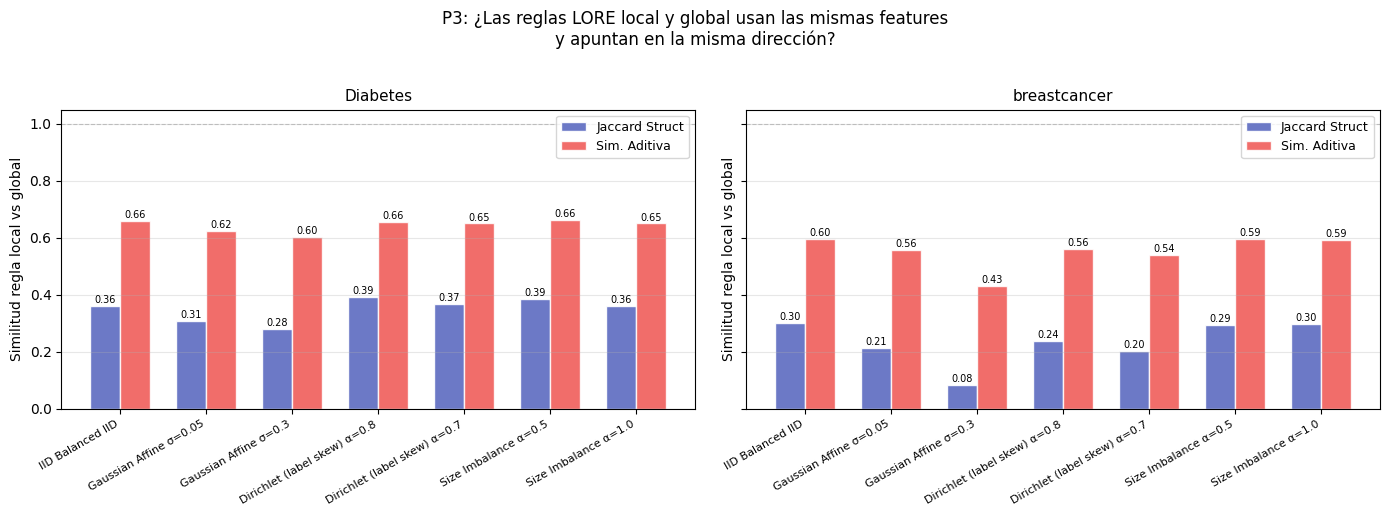

In [16]:

# ===========================================================
# P3: ¿Las explicaciones LORE locales y globales razonan
#     sobre las mismas variables?
#
# jaccard_lore_struct  → Jaccard entre el conjunto de features
#                        que aparecen en la regla local vs global
#                        (¿qué variables usan?)
# sim_aditiva_lore     → Similitud aditiva entre condiciones:
#                        tiene en cuenta dirección y magnitud
#                        (¿las condiciones son parecidas?)
# ===========================================================

ORDER = [
    'IID Balanced IID',
    'Gaussian Affine σ=0.05',
    'Gaussian Affine σ=0.3',
    'Dirichlet (label skew) α=0.8',
    'Dirichlet (label skew) α=0.7',
    'Size Imbalance α=0.5',
    'Size Imbalance α=1.0',
]

datasets = sorted(df_all['dataset'].unique())

# ── Tabla ──────────────────────────────────────────────────
print("=" * 70)
print("  P3: SIMILITUD ESTRUCTURAL DE REGLAS LORE local vs global")
print("  (media sobre 4/6/8 clientes)")
print("=" * 70)
for dataset in datasets:
    sub   = df_all[df_all['dataset'] == dataset]
    tabla = (
        sub.groupby('label')[['jaccard_lore_struct', 'sim_aditiva_lore']]
           .mean()
           .rename(columns={'jaccard_lore_struct': 'Jaccard Struct',
                            'sim_aditiva_lore':    'Sim. Aditiva'})
    )
    tabla = tabla.reindex([o for o in ORDER if o in tabla.index])
    tabla['Diff (J-S)'] = tabla['Jaccard Struct'] - tabla['Sim. Aditiva']
    print(f"\n  {dataset}")
    print(tabla.to_string(float_format='{:.3f}'.format))

# ── Gráfica ────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(datasets), figsize=(7 * len(datasets), 5), sharey=True)
if len(datasets) == 1:
    axes = [axes]

for ax, dataset in zip(axes, datasets):
    sub   = df_all[df_all['dataset'] == dataset]
    tabla = (
        sub.groupby('label')[['jaccard_lore_struct', 'sim_aditiva_lore']]
           .mean()
           .reindex([o for o in ORDER if o in sub['label'].unique()])
    )
    x     = np.arange(len(tabla))
    width = 0.35

    bars_j = ax.bar(x - width/2, tabla['jaccard_lore_struct'],
                    width, color='#5C6BC0', alpha=0.9, edgecolor='white',
                    label='Jaccard Struct')
    bars_s = ax.bar(x + width/2, tabla['sim_aditiva_lore'],
                    width, color='#EF5350', alpha=0.85, edgecolor='white',
                    label='Sim. Aditiva')

    ax.set_xticks(x)
    ax.set_xticklabels(tabla.index, rotation=30, ha='right', fontsize=8)
    ax.set_ylim(0.0, 1.05)
    ax.set_title(dataset, fontsize=11)
    ax.set_ylabel('Similitud regla local vs global')
    ax.axhline(1.0, color='grey', linestyle='--', linewidth=0.8, alpha=0.4)
    ax.grid(axis='y', alpha=0.3)

    for bar in list(bars_j) + list(bars_s):
        h = bar.get_height()
        if not np.isnan(h):
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.003,
                    f'{h:.2f}', ha='center', va='bottom', fontsize=7)

    ax.legend(fontsize=9, loc='upper right')

plt.suptitle('P3: ¿Las reglas LORE local y global usan las mismas features\ny apuntan en la misma dirección?',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


**¿Usan las reglas LORE de bb_local y bb_global las mismas variables y en el mismo sentido?**

Dos métricas distintas responden esto:
- **Jaccard Struct:** ¿usan las mismas features? Si bb_local usa {glucosa, BMI} y bb_global usa {glucosa, edad}, el Jaccard es 1/3 ≈ 0.33.
- **Sim. Aditiva:** cuando coinciden en una feature, ¿las condiciones apuntan en el mismo sentido y con rangos similares? Es más permisiva que el Jaccard.

El Jaccard Struct es bajo en todos los escenarios: ~0.36 en Diabetes y ~0.30 en BreastCancer incluso en IID. No es un efecto del non-IID — es una propiedad del propio LORE: la generación del vecindario es estocástica y produce árboles con features distintas en cada modelo.

La Sim. Aditiva es siempre más alta (~0.65 Diabetes, ~0.60 BreastCancer en IID): cuando los dos modelos coinciden en una variable, las condiciones apuntan en la misma dirección. El problema no es que se contradigan, sino que cada modelo elige variables distintas para explicar.

**Conclusión:** la similitud estructural es moderada-baja incluso en IID y empeora bajo heterogeneidad fuerte. El riesgo es que el usuario reciba una explicación global basada en variables distintas a las que usa su modelo local — no porque se contradigan, sino porque el método elige features diferentes.

## Accuracy y fidelidad del árbol surrogate LORE

Dos métricas distintas sobre el árbol surrogate de LORE:

- **Accuracy** (`acc_localTree_localTest` / `acc_localTree_globalTest`): ¿cuántas instancias clasifica correctamente el árbol respecto a las **etiquetas reales**? Mide si el árbol es un buen clasificador.
- **Fidelidad** (`tree_fidelity_lore_local` / `tree_fidelity_lore_global`): ¿en qué fracción de instancias el árbol replica la **predicción del NN** (no la etiqueta real)? Mide si el árbol imita bien al modelo que explica.

La diferencia es importante: un árbol puede tener alta fidelidad al NN y baja accuracy si el propio NN se equivoca mucho. Y al revés: bajo Gaussian σ=0.05 el árbol tiene mayor accuracy que el NN_local porque se construye sobre el vecindario del test, no sobre los datos de entrenamiento corrompidos.

  LORE: ACCURACY + FIDELIDAD DEL ÁRBOL SURROGATE  (media sobre 4/6/8 clientes)

  Diabetes
                              Acc test=local  Acc test=global  Fidelidad bb_local  Fidelidad bb_global
label                                                                                                 
IID Balanced IID                       0.682            0.720               0.966                0.971
Gaussian Affine σ=0.05                 0.679            0.720               0.965                0.970
Gaussian Affine σ=0.3                  0.602            0.612               0.967                0.971
Dirichlet (label skew) α=0.8           0.779            0.667               0.972                0.974
Dirichlet (label skew) α=0.7           0.783            0.669               0.977                0.973
Size Imbalance α=0.5                   0.692            0.720               0.965                0.971
Size Imbalance α=1.0                   0.706            0.731               0.963    

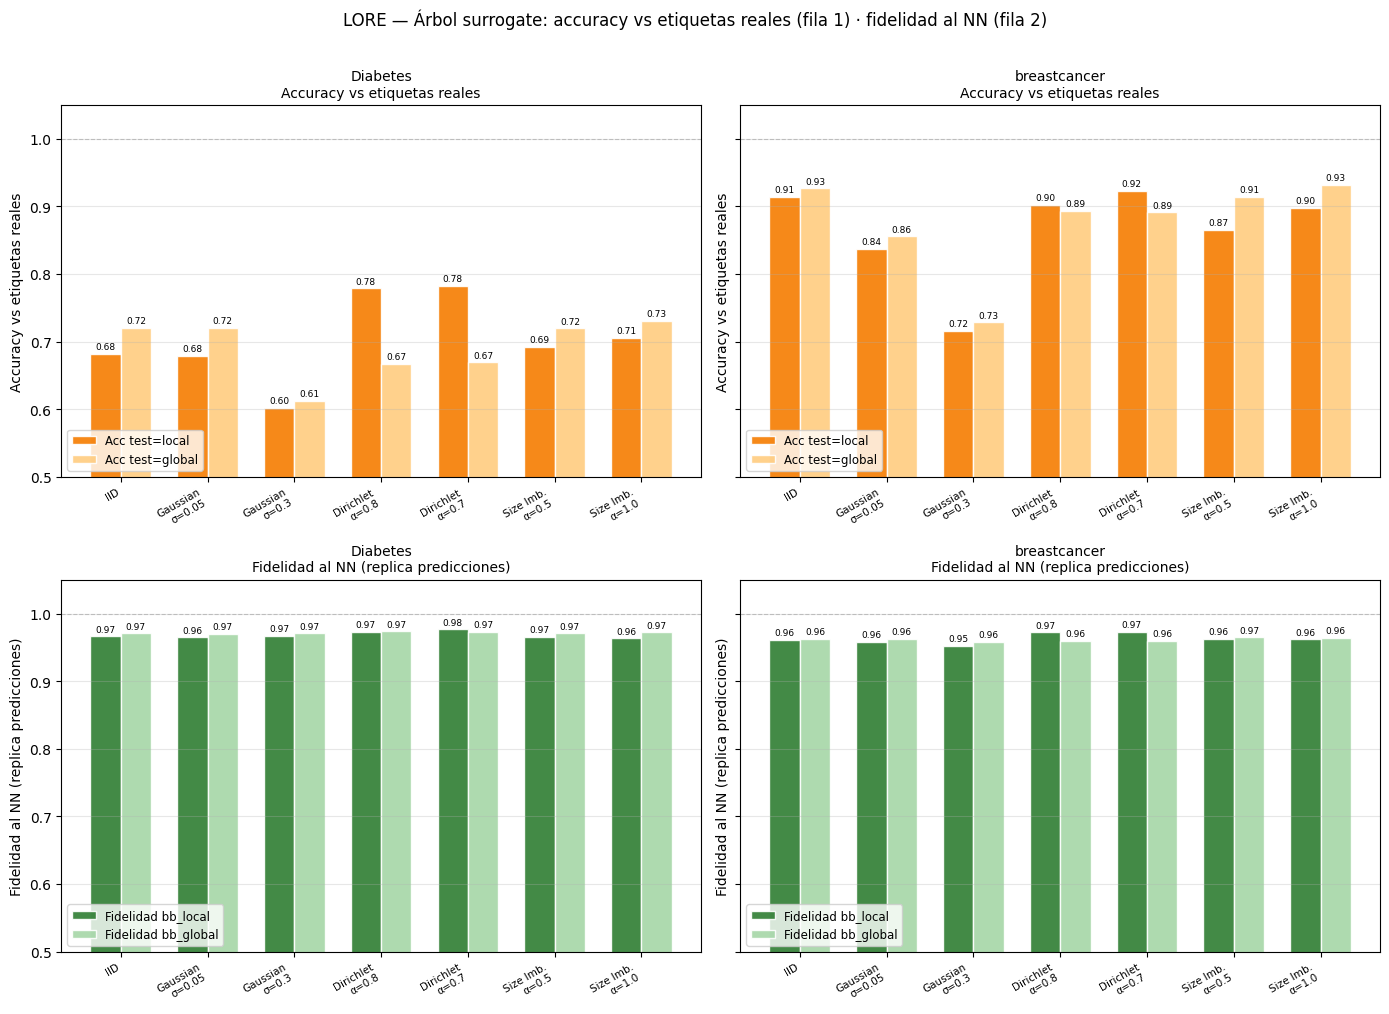

In [17]:
# ===========================================================
# LORE: Accuracy del árbol surrogate + Fidelidad al NN
#
# acc_localTree_localTest   → accuracy del árbol vs etiquetas reales (test local)
# acc_localTree_globalTest  → accuracy del árbol vs etiquetas reales (test global)
# tree_fidelity_lore_local  → % instancias donde el árbol replica bb_local
# tree_fidelity_lore_global → % instancias donde el árbol replica bb_global
# ===========================================================

ORDER = [
    'IID Balanced IID',
    'Gaussian Affine σ=0.05',
    'Gaussian Affine σ=0.3',
    'Dirichlet (label skew) α=0.8',
    'Dirichlet (label skew) α=0.7',
    'Size Imbalance α=0.5',
    'Size Imbalance α=1.0',
]

ACC_KEYS = ['acc_localTree_localTest', 'acc_localTree_globalTest']
FID_KEYS = ['tree_fidelity_lore_local', 'tree_fidelity_lore_global']
ALL_KEYS = ACC_KEYS + FID_KEYS
datasets = sorted(df_all['dataset'].unique())

# ── Tabla ──────────────────────────────────────────────────
print("=" * 80)
print("  LORE: ACCURACY + FIDELIDAD DEL ÁRBOL SURROGATE  (media sobre 4/6/8 clientes)")
print("=" * 80)
for dataset in datasets:
    sub  = df_all[df_all['dataset'] == dataset]
    keys = [k for k in ALL_KEYS if k in sub.columns]
    tabla = (
        sub.groupby('label')[keys].mean()
           .reindex([o for o in ORDER if o in sub['label'].unique()])
           .rename(columns={
               'acc_localTree_localTest':  'Acc test=local',
               'acc_localTree_globalTest': 'Acc test=global',
               'tree_fidelity_lore_local':  'Fidelidad bb_local',
               'tree_fidelity_lore_global': 'Fidelidad bb_global',
           })
    )
    print(f"\n  {dataset}")
    print(tabla.to_string(float_format='{:.3f}'.format))

# ── Gráfica: 2 filas × n_datasets ─────────────────────────
short_labels = lambda lst: [
    o.replace('Dirichlet (label skew) ', 'Dirichlet\n')
     .replace('Gaussian Affine ', 'Gaussian\n')
     .replace('Size Imbalance ', 'Size Imb.\n')
     .replace('IID Balanced ', '') for o in lst
]

rows_cfg = [
    (ACC_KEYS, ['#F57C00', '#FFCC80'], ['Acc test=local', 'Acc test=global'],
     'Accuracy vs etiquetas reales'),
    (FID_KEYS, ['#2E7D32', '#A5D6A7'], ['Fidelidad bb_local', 'Fidelidad bb_global'],
     'Fidelidad al NN (replica predicciones)'),
]

fig, axes = plt.subplots(2, len(datasets), figsize=(7 * len(datasets), 10), sharey='row')

for row_idx, (keys, colors, labels, row_title) in enumerate(rows_cfg):
    avail = [k for k in keys if k in df_all.columns]
    for col_idx, dataset in enumerate(datasets):
        ax    = axes[row_idx, col_idx]
        sub   = df_all[df_all['dataset'] == dataset]
        orden = [o for o in ORDER if o in sub['label'].unique()]
        t     = sub.groupby('label')[avail].mean().reindex(orden)

        x     = np.arange(len(t))
        width = 0.35

        bars0 = ax.bar(x - width/2, t[avail[0]], width,
                       color=colors[0], alpha=0.9, edgecolor='white', label=labels[0])
        bars1 = ax.bar(x + width/2, t[avail[1]], width,
                       color=colors[1], alpha=0.9, edgecolor='white', label=labels[1])

        ax.set_xticks(x)
        ax.set_xticklabels(short_labels(orden), rotation=30, ha='right', fontsize=7.5)
        ax.set_ylim(0.5, 1.05)
        ax.set_title(f'{dataset}\n{row_title}', fontsize=10)
        ax.set_ylabel(row_title)
        ax.axhline(1.0, color='grey', linestyle='--', linewidth=0.8, alpha=0.4)
        ax.grid(axis='y', alpha=0.3)
        ax.legend(fontsize=8.5, loc='lower left')

        for bar in list(bars0) + list(bars1):
            h = bar.get_height()
            if not np.isnan(h):
                ax.text(bar.get_x() + bar.get_width()/2, h + 0.004,
                        f'{h:.2f}', ha='center', va='bottom', fontsize=6.5)

plt.suptitle('LORE — Árbol surrogate: accuracy vs etiquetas reales (fila 1) · fidelidad al NN (fila 2)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()


**Fidelidad — alta y sin variación.** En todos los escenarios y ambos datasets se mueve entre 0.952 y 0.977. La heterogeneidad no afecta a la capacidad del surrogate de imitar al NN: LORE construye cada árbol en el vecindario local de la instancia, no sobre los datos de entrenamiento, por lo que el tipo de non-IID no interfiere en la fidelidad.

**Accuracy en Dirichlet — el árbol hereda el patrón del bb_local.** En Diabetes, Acc test=local (0.779–0.783) > Acc test=global (0.667–0.669), igual que ocurría con bb_local. Al ser fiel al modelo local, el surrogate hereda también su mayor acierto en el espacio sesgado del cliente.

**Accuracy en Gaussian σ=0.05 BreastCancer — el árbol supera al bb_local.** Acc test=local = 0.837 frente a bb_local/test=local = 0.677. No hay contradicción con la alta fidelidad (0.958): accuracy y fidelidad miden cosas distintas. El árbol surrogate se entrena sobre el espacio del test — menos afectado por la distorsión gaussiana del entrenamiento —, mientras que bb_local fue entrenado sobre datos corrompidos. El surrogate puede replicar las predicciones del NN en el vecindario de cada instancia de test y aun así acertar más veces que el propio NN a nivel global.

# Conclusión sobre LORE

Cuando LORE explica la predicción de un modelo, construye una regla del tipo "si glucosa < 120 y BMI < 25, entonces clase A". La pregunta es: ¿la regla del bb_local y la del bb_global son comparables? Los datos dan tres respuestas:

1. **El surrogate imita bien al NN** (fidelidad ~0.96–0.97 en todos los escenarios) — las reglas son técnicamente correctas respecto a lo que el modelo hace. La heterogeneidad no afecta a esto.

2. **Cubren instancias parecidas** (jaccard_cov 60–77%) — bb_local y bb_global generan regla para más o menos los mismos pacientes. Con la excepción de Dirichlet α=0.7, donde el Jaccard cae a ~0.63 y la disponibilidad a ~0.70 — los valores más bajos del análisis en ambos casos — porque el label skew hace que más instancias queden cerca de la frontera de decisión sin regla posible.

3. **No usan las mismas features** (Jaccard struct ~0.3) — uno dice "glucosa y BMI", el otro dice "glucosa y edad". Cuando coinciden en una variable, las condiciones apuntan en la misma dirección (Sim. Aditiva ~0.65), así que el problema no es que se contradigan sino que cada modelo elige variables distintas para explicar.

El resultado: bb_local y bb_global predicen igual, sus surrogates los imitan bien, explican los mismos pacientes — pero cuando lees la explicación, cada uno destaca variables distintas. La explicación global no te dice cómo razona tu modelo local.

Y esto ocurre incluso en IID — no es un problema del non-IID. La heterogeneidad (especialmente Dirichlet) lo agrava al reducir disponibilidad y solapamiento, pero el problema de fondo es estructural del propio LORE: la generación del vecindario es estocástica y puede seleccionar features distintas en cada ejecución, aunque el modelo subyacente sea el mismo.

**Limitación y trabajo futuro:** el Jaccard struct bajo (~0.3) refleja en parte variabilidad del método, no solo divergencia entre modelos. 

Dos mejoras posibles serían:

1. Ejecutar LORE varias veces por instancia y quedarse con las features que aparecen más consistentemente (votación)

2. Fijar el conjunto de features de referencia a partir de importancias globales (p.ej. SHAP) antes de generar el vecindario.

---

# LIME

## Delta LIME

`delta_lime_testglobal`: Las perturbaciones se generan según la distribución global. Pregunta: ¿cuánto difieren bb_local y bb_global cuando el contexto es la distribución global?

`delta_lime_testlocal`: Las perturbaciones se generan según la distribución del test local del cliente. Pregunta: ¿cuánto difieren bb_local y bb_global en cómo explican esta instancia cuando el contexto de referencia es la distribución local?

Un delta bajo significa que ambos modelos asignan importancias similares a las mismas features.

Un delta alto significa que la importancia que asigna uno y otro a las features es distinta — los modelos están priorizando variables diferentes para explicar sus predicciones.

| delta_lime_testlocal | delta_lime_testglobal | Interpretación |
|---|---|---|
| Alto | Alto | Los surrogates lineales difieren en ambos contextos → bb_local y bb_global asignan importancias muy distintas a las features independientemente de la distribución usada para perturbar. Divergencia estructural entre modelos. |
| Bajo | Bajo | Los surrogates coinciden en ambos contextos → la federación ha alineado bien los dos modelos, explican de forma similar tanto en contexto local como global. |
| Alto | Bajo | Los surrogates difieren más cuando las perturbaciones vienen de la distribución local → bb_global no aproxima bien el comportamiento de bb_local en la zona del espacio característica del cliente. |
| Bajo | Alto | Los surrogates difieren más cuando las perturbaciones vienen de la distribución global → bb_local y bb_global coinciden en el contexto local del cliente, pero divergen en contexto global, lo que puede indicar que el cliente tiene una distribución muy distinta al resto de clientes. |

  LIME: DELTA — diferencia media de importancias local vs global
  (media sobre 4/6/8 clientes)

  Diabetes
                              Global Test  Local Test  Diff (G-L)
label                                                            
IID Balanced IID                   0.0824      0.0795      0.0029
Gaussian Affine σ=0.05             0.0839      0.0796      0.0043
Gaussian Affine σ=0.3              0.0923      0.0888      0.0035
Dirichlet (label skew) α=0.8       0.1121      0.1033      0.0088
Dirichlet (label skew) α=0.7       0.1165      0.1121      0.0044
Size Imbalance α=0.5               0.0806      0.0804      0.0002
Size Imbalance α=1.0               0.0852      0.0832      0.0020

  breastcancer
                              Global Test  Local Test  Diff (G-L)
label                                                            
IID Balanced IID                   0.0164      0.0166     -0.0002
Gaussian Affine σ=0.05             0.0259      0.0246      0.0013
Gaussian Affine σ=

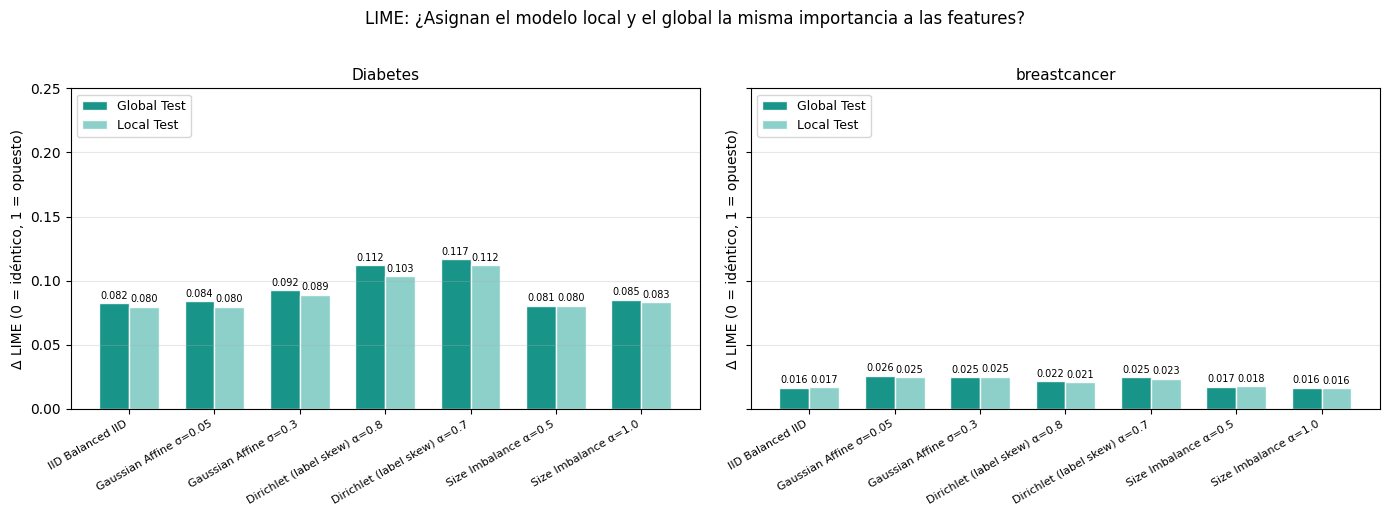

In [11]:

# ===========================================================
# LIME: ¿Asignan el modelo local y el global la misma
#       importancia a las mismas features?
# Métrica: delta_lime_testglobal / delta_lime_testlocal
#   → diferencia media (L1) entre los vectores de importancia
#     del modelo local y del global, normalizados a L1=1
#   → 0 = idénticos; 1 = completamente distintos
# ===========================================================

ORDER = [
    'IID Balanced IID',
    'Gaussian Affine σ=0.05',
    'Gaussian Affine σ=0.3',
    'Dirichlet (label skew) α=0.8',
    'Dirichlet (label skew) α=0.7',
    'Size Imbalance α=0.5',
    'Size Imbalance α=1.0',
]

datasets = sorted(df_all['dataset'].unique())

# ── Tabla ──────────────────────────────────────────────────
print("=" * 70)
print("  LIME: DELTA — diferencia media de importancias local vs global")
print("  (media sobre 4/6/8 clientes)")
print("=" * 70)
for dataset in datasets:
    sub   = df_all[df_all['dataset'] == dataset]
    tabla = (
        sub.groupby('label')[['delta_lime_testglobal', 'delta_lime_testlocal']]
           .mean()
           .rename(columns={'delta_lime_testglobal': 'Global Test',
                            'delta_lime_testlocal':  'Local Test'})
    )
    tabla = tabla.reindex([o for o in ORDER if o in tabla.index])
    tabla['Diff (G-L)'] = tabla['Global Test'] - tabla['Local Test']
    print(f"\n  {dataset}")
    print(tabla.to_string(float_format='{:.4f}'.format))

# ── Gráfica ────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(datasets), figsize=(7 * len(datasets), 5), sharey=True)
if len(datasets) == 1:
    axes = [axes]

for ax, dataset in zip(axes, datasets):
    sub   = df_all[df_all['dataset'] == dataset]
    tabla = (
        sub.groupby('label')[['delta_lime_testglobal', 'delta_lime_testlocal']]
           .mean()
           .reindex([o for o in ORDER if o in sub['label'].unique()])
    )
    x     = np.arange(len(tabla))
    width = 0.35

    COLOR_DARK  = '#00897B'   # verde azulado oscuro → Global Test
    COLOR_LIGHT = '#80CBC4'   # verde azulado claro  → Local Test

    bars_g = ax.bar(x - width/2, tabla['delta_lime_testglobal'],
                    width, color=COLOR_DARK,  alpha=0.9, edgecolor='white',
                    label='Global Test')
    bars_l = ax.bar(x + width/2, tabla['delta_lime_testlocal'],
                    width, color=COLOR_LIGHT, alpha=0.9, edgecolor='white',
                    label='Local Test')

    ax.set_xticks(x)
    ax.set_xticklabels(tabla.index, rotation=30, ha='right', fontsize=8)
    ax.set_ylim(0.0, 0.25)
    ax.set_title(dataset, fontsize=11)
    ax.set_ylabel('Δ LIME (0 = idéntico, 1 = opuesto)')
    ax.grid(axis='y', alpha=0.3)

    for bar in list(bars_g) + list(bars_l):
        h = bar.get_height()
        if not np.isnan(h):
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.002,
                    f'{h:.3f}', ha='center', va='bottom', fontsize=7)

    ax.legend(fontsize=9, loc='upper left')

plt.suptitle('LIME: ¿Asignan el modelo local y el global la misma importancia a las features?',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


**¿Asignan el bb_local y el bb_global la misma importancia a las features según LIME?**

En general sí — ambos deltas (Global Test y Local Test) son bajos en todos los escenarios, lo que significa que bb_local y bb_global asignan importancias similares independientemente de si las perturbaciones vienen de la distribución local o de la global.

**Diabetes** (8 features): delta en torno a 0.08–0.09 en IID y escenarios de imbalance. Sube a ~0.11–0.12 en Dirichlet, que es el único escenario donde la heterogeneidad de clases introduce algo más de divergencia en las importancias. Aun así, sigue siendo bajo en términos absolutos.

**BreastCancer** (30 features): valores entre 0.016 y 0.026 — incluso más bajos. Esto es en parte un artefacto de escala: al normalizar L1=1 sobre 30 variables, cada feature tiene un peso pequeño, por lo que las diferencias numéricas son diminutas. La heterogeneidad apenas mueve el delta.

**Conclusión:** LIME muestra que la federación alinea bien los vectores de importancia de ambos modelos. La excepción más notable es Dirichlet en Diabetes, donde el label skew introduce algo más de divergencia — pero incluso ahí es moderada.

Sin embargo, el delta tiene una limitación: se calcula normalizando el vector de importancias para que la suma de valores absolutos sea 1. Con 30 features eso significa que cada feature ocupa ~1/30 del total, así que aunque dos modelos ordenen las features de forma distinta, la diferencia numérica por feature es diminuta — el delta sale bajo no porque los modelos coincidan más, sino porque el denominador es mayor. SHAP, al comparar el vector completo sin ese efecto de escala relativa, encontraba más divergencia en BreastCancer (0.033–0.048 frente a 0.016–0.026 de LIME). LIME es útil como métrica complementaria, pero no suficiente por sí sola en alta dimensión.

**Mejora propuesta:** en lugar del delta sobre el vector completo, comparar el ranking de las top-k features (p.ej. top-3 o top-5). Dos modelos pueden tener delta bajo pero ordenar las features de forma distinta, y eso es lo que le importa al usuario final que lee la explicación.

---

## Delta SHAP

`delta_shap_testglobal` / `delta_shap_testlocal` — diferencia media entre los vectores de valores SHAP de bb_local y bb_global, normalizados a L1=1. Mismo concepto que el delta LIME pero con SHAP: mide si ambos modelos atribuyen la misma importancia a las mismas features. La diferencia clave respecto a LIME es que SHAP compara el vector completo de todas las features, lo que lo hace más sensible a divergencias en features secundarias.

Un delta bajo → ambos modelos explican igual.

Un delta alto → priorizan features distintas.

| delta_shap_testlocal | delta_shap_testglobal | Interpretación |
|---|---|---|
| Alto | Alto | Los modelos difieren en ambos contextos → divergencia estructural entre bb_local y bb_global, independientemente de la distribución. La federación no ha conseguido alinear los dos modelos. |
| Bajo | Bajo | Los modelos coinciden en ambos contextos → la federación ha funcionado bien, bb_local y bb_global explican de forma similar tanto en contexto local como global. |
| Alto | Bajo | Los modelos difieren más en contexto local → bb_global no captura bien los patrones específicos del cliente, pero se comporta de forma similar a bb_local en contexto global. |
| Bajo | Alto | Los modelos difieren más en contexto global → bb_local y bb_global coinciden en el contexto local del cliente, pero divergen cuando se evalúan sobre la distribución global, lo que puede indicar que el cliente tiene una distribución muy distinta al resto. |

  SHAP: DELTA — diferencia media de importancias local vs global
  (media sobre 4/6/8 clientes)

  Diabetes
                              Global Test  Local Test  Diff (G-L)
label                                                            
IID Balanced IID                   0.0842      0.0814      0.0029
Gaussian Affine σ=0.05             0.0853      0.0830      0.0023
Gaussian Affine σ=0.3              0.0985      0.0952      0.0033
Dirichlet (label skew) α=0.8       0.1123      0.1088      0.0035
Dirichlet (label skew) α=0.7       0.1155      0.1110      0.0045
Size Imbalance α=0.5               0.0784      0.0786     -0.0002
Size Imbalance α=1.0               0.0840      0.0843     -0.0003

  breastcancer
                              Global Test  Local Test  Diff (G-L)
label                                                            
IID Balanced IID                   0.0479      0.0391      0.0088
Gaussian Affine σ=0.05             0.0475      0.0412      0.0064
Gaussian Affine σ=

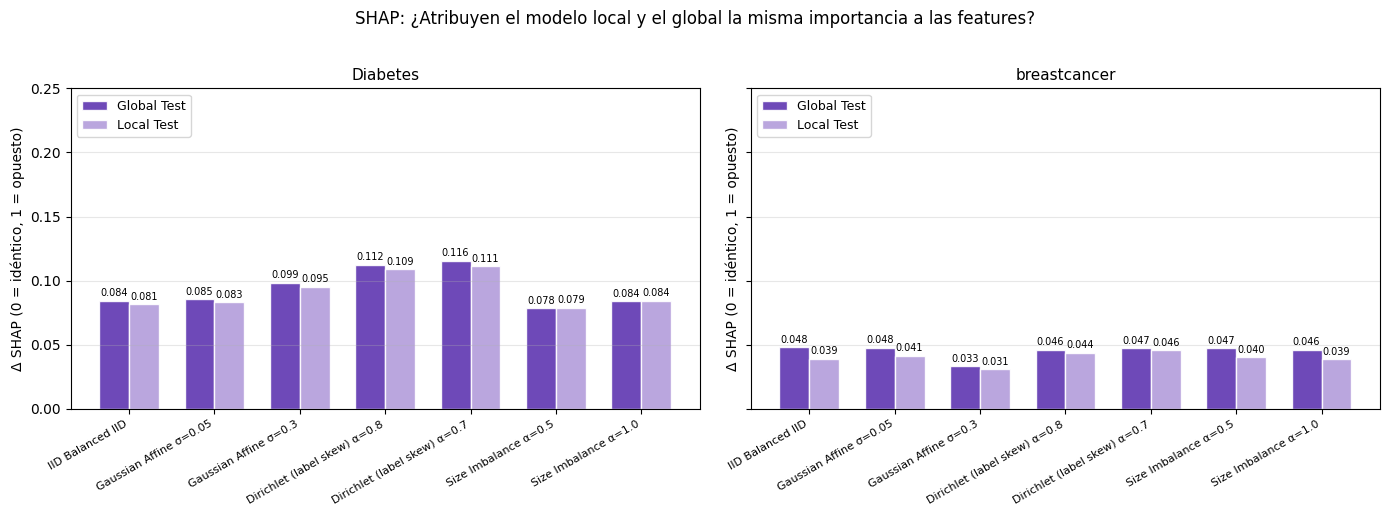

In [12]:
# ===========================================================
# SHAP: ¿Atribuyen el modelo local y el global la misma
#       importancia a las mismas features?
# Métrica: delta_shap_testglobal / delta_shap_testlocal
#   → diferencia media (L1) entre vectores SHAP normalizados
#   → 0 = idénticos; 1 = completamente distintos
# ===========================================================

ORDER = [
    'IID Balanced IID',
    'Gaussian Affine σ=0.05',
    'Gaussian Affine σ=0.3',
    'Dirichlet (label skew) α=0.8',
    'Dirichlet (label skew) α=0.7',
    'Size Imbalance α=0.5',
    'Size Imbalance α=1.0',
]

datasets = sorted(df_all['dataset'].unique())

# ── Tabla ──────────────────────────────────────────────────
print("=" * 70)
print("  SHAP: DELTA — diferencia media de importancias local vs global")
print("  (media sobre 4/6/8 clientes)")
print("=" * 70)
for dataset in datasets:
    sub   = df_all[df_all['dataset'] == dataset]
    tabla = (
        sub.groupby('label')[['delta_shap_testglobal', 'delta_shap_testlocal']]
           .mean()
           .rename(columns={'delta_shap_testglobal': 'Global Test',
                            'delta_shap_testlocal':  'Local Test'})
    )
    tabla = tabla.reindex([o for o in ORDER if o in tabla.index])
    tabla['Diff (G-L)'] = tabla['Global Test'] - tabla['Local Test']
    print(f"\n  {dataset}")
    print(tabla.to_string(float_format='{:.4f}'.format))

# ── Gráfica ────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(datasets), figsize=(7 * len(datasets), 5), sharey=True)
if len(datasets) == 1:
    axes = [axes]

for ax, dataset in zip(axes, datasets):
    sub   = df_all[df_all['dataset'] == dataset]
    tabla = (
        sub.groupby('label')[['delta_shap_testglobal', 'delta_shap_testlocal']]
           .mean()
           .reindex([o for o in ORDER if o in sub['label'].unique()])
    )
    x     = np.arange(len(tabla))
    width = 0.35

    COLOR_DARK  = '#5E35B1'   # púrpura oscuro → Global Test
    COLOR_LIGHT = '#B39DDB'   # púrpura claro  → Local Test

    bars_g = ax.bar(x - width/2, tabla['delta_shap_testglobal'],
                    width, color=COLOR_DARK,  alpha=0.9, edgecolor='white',
                    label='Global Test')
    bars_l = ax.bar(x + width/2, tabla['delta_shap_testlocal'],
                    width, color=COLOR_LIGHT, alpha=0.9, edgecolor='white',
                    label='Local Test')

    ax.set_xticks(x)
    ax.set_xticklabels(tabla.index, rotation=30, ha='right', fontsize=8)
    ax.set_ylim(0.0, 0.25)
    ax.set_title(dataset, fontsize=11)
    ax.set_ylabel('Δ SHAP (0 = idéntico, 1 = opuesto)')
    ax.grid(axis='y', alpha=0.3)

    for bar in list(bars_g) + list(bars_l):
        h = bar.get_height()
        if not np.isnan(h):
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.002,
                    f'{h:.3f}', ha='center', va='bottom', fontsize=7)

    ax.legend(fontsize=9, loc='upper left')

plt.suptitle('SHAP: ¿Atribuyen el modelo local y el global la misma importancia a las features?',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

**¿Atribuyen el bb_local y el bb_global la misma importancia a las features según SHAP?**

En general sí — ambos deltas (Global Test y Local Test) son bajos en todos los escenarios, igual que LIME. Pero SHAP aporta matices que LIME no veía:

**Diabetes** (8 features): delta entre 0.078 y 0.116. Mismo patrón que LIME — Dirichlet es el escenario con mayor divergencia (~0.11–0.12), Size Imbalance el más alineado (~0.08).

**BreastCancer** (30 features): SHAP da valores más altos que LIME — entre 0.033 y 0.048 frente a 0.016–0.026 de LIME. Esto es informativo: LIME solo compara las features más importantes (que suelen coincidir entre ambos modelos) mientras que SHAP compara el vector completo. La diferencia indica que los modelos comparten las features más relevantes pero divergen en cómo distribuyen la importancia del resto.

**Paradoja en Gaussian σ=0.3 + BreastCancer:** es el escenario con peor acuerdo de predicciones (0.436) pero tiene el delta SHAP más bajo de todos los escenarios de BreastCancer (0.033/0.031). Aunque los modelos predicen de forma muy distinta, ambos identifican las mismas features como las más relevantes — lo que cambia es cómo aplican esa información, no qué información usan. Este patrón sugiere que ambos modelos tienen fronteras de decisión en zonas distintas del espacio, pero razonan con las mismas variables.

**Conclusión:** los resultados son positivos — la federación alinea bien las importancias de features en ambos datasets. SHAP añade valor sobre LIME al capturar el vector completo y detectar la divergencia moderada en BreastCancer que LIME ocultaba por el efecto de escala.

**Limitación:** el delta se calcula sobre los valores absolutos normalizados, por lo que pierde información de signo. 

Ejemplo: si bb_local asigna SHAP = +0.3 a glucosa (glucosa alta → más riesgo) y bb_global asigna SHAP = −0.3 (glucosa alta → menos riesgo), ambos contribuyen 0.3/total tras normalizar y el delta para esa feature es 0. 

los modelos interpretan la feature en sentido contrario pero el delta no lo detecta.

**Mejoras propuestas:** comparar el ranking de features (correlación de Spearman entre vectores) en lugar del delta, más robusto al efecto de escala; y separar importancias positivas y negativas para detectar casos donde los modelos coinciden en magnitud pero no en dirección.

---

# ANCHOR

Para cada instancia de test se generan cuatro explicaciones Anchor, combinando los dos modelos (`bb_local`, `bb_global`) con los dos backgrounds (`X_test_local`, `X_test_global`). De cada una se extraen tres métricas:

- **Precisión** (`anchor_prec_*`) — proporción de perturbaciones que cumplen la regla y mantienen la misma predicción. Por construcción siempre supera el umbral de 0.85.
- **Cobertura** (`anchor_cov_*`) — fracción del espacio de perturbación que satisface la regla. Reglas más restrictivas → menor cobertura.
- **Disponibilidad** (`ratio_has_anchor_*`) — fracción de instancias donde Anchor encontró una regla válida.

La comparación más informativa es **mismo background, distinto modelo** (e.g. `testlocal_local` vs `testlocal_global`), que aísla el efecto del modelo eliminando el efecto del contexto de perturbación.

## Precisión y cobertura


  Anchor PRECISIÓN — Diabetes
                              local/test=local  global/test=local  local/test=global  global/test=global  Δ test=local  Δ test=global
label                                                                                                                                
IID Balanced IID                         0.915              0.931              0.899               0.915         0.016          0.016
Gaussian Affine σ=0.05                   0.911              0.925              0.900               0.916         0.014          0.015
Gaussian Affine σ=0.3                    0.923              0.936              0.911               0.914         0.013          0.002
Dirichlet (label skew) α=0.8             0.928              0.847              0.910               0.915        -0.081          0.005
Dirichlet (label skew) α=0.7             0.923              0.957              0.906               0.936         0.034          0.030
Size Imbalance α=0.5           

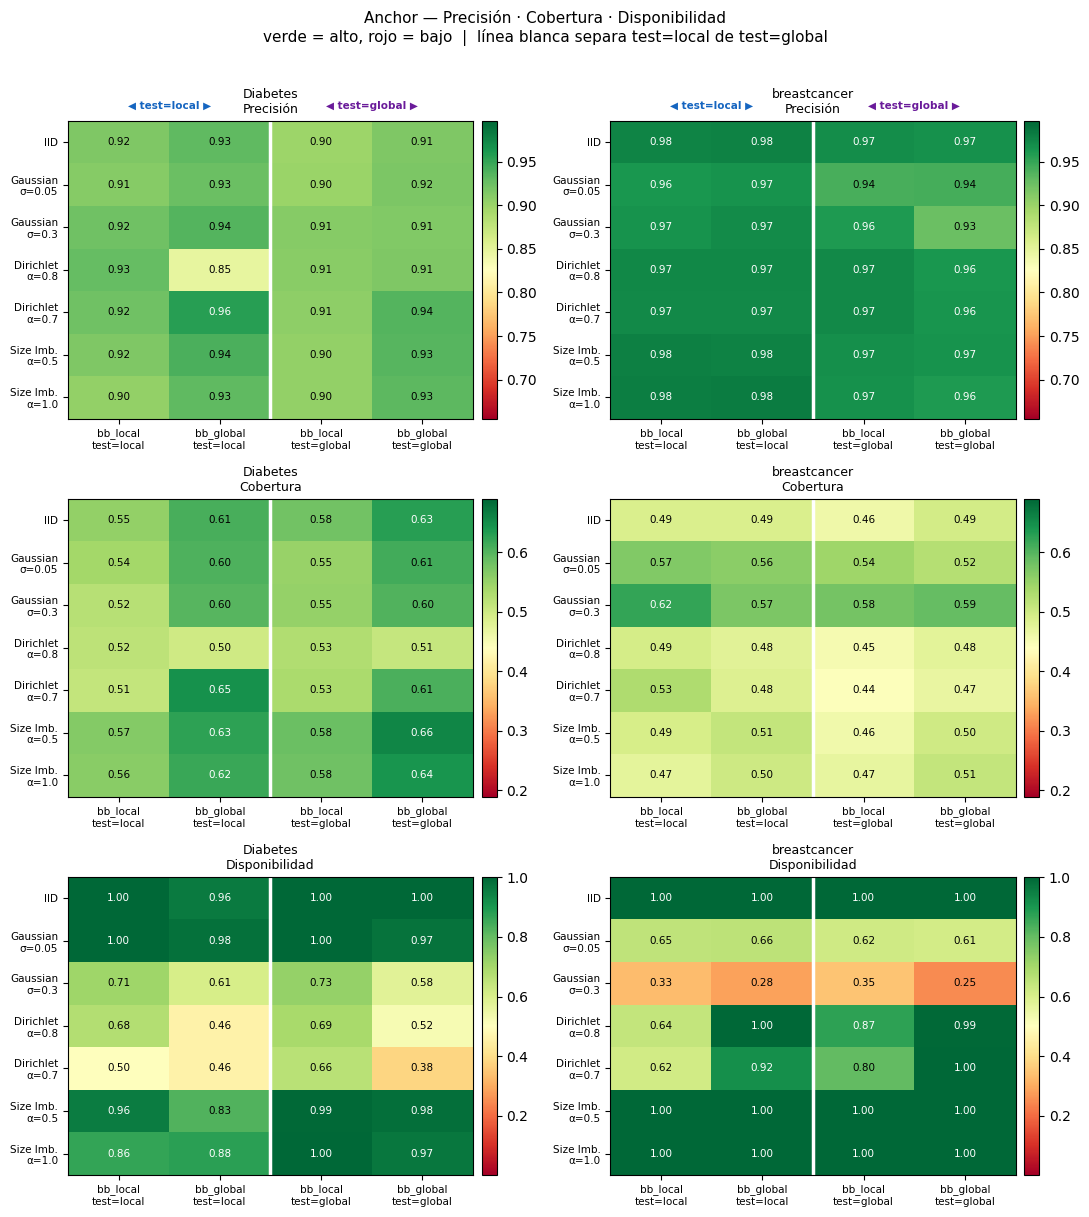

In [19]:

# ===========================================================
# Anchor: precisión, cobertura y disponibilidad — heatmaps
# Columnas: bb_local | bb_global (test=local) ║ bb_local | bb_global (test=global)
# ===========================================================

ORDER = [
    'IID Balanced IID',
    'Gaussian Affine σ=0.05',
    'Gaussian Affine σ=0.3',
    'Dirichlet (label skew) α=0.8',
    'Dirichlet (label skew) α=0.7',
    'Size Imbalance α=0.5',
    'Size Imbalance α=1.0',
]

PREC_KEYS   = ['anchor_prec_testlocal_local', 'anchor_prec_testlocal_global',
               'anchor_prec_testglobal_local', 'anchor_prec_testglobal_global']
COV_KEYS    = ['anchor_cov_testlocal_local',  'anchor_cov_testlocal_global',
               'anchor_cov_testglobal_local',  'anchor_cov_testglobal_global']
RATIO_KEYS  = ['ratio_has_anchor_testlocal_local',  'ratio_has_anchor_testlocal_global',
               'ratio_has_anchor_testglobal_local',  'ratio_has_anchor_testglobal_global']

COL_LABELS  = ['bb_local\ntest=local', 'bb_global\ntest=local',
               'bb_local\ntest=global', 'bb_global\ntest=global']

datasets = sorted(df_all['dataset'].unique())

# ── Tablas ─────────────────────────────────────────────────
for keys, title in [(PREC_KEYS, 'PRECISIÓN'), (COV_KEYS, 'COBERTURA'), (RATIO_KEYS, 'DISPONIBILIDAD')]:
    for dataset in datasets:
        sub   = df_all[df_all['dataset'] == dataset]
        orden = [o for o in ORDER if o in sub['label'].unique()]
        t = sub.groupby('label')[keys].mean().reindex(orden)
        t.columns = ['local/test=local', 'global/test=local', 'local/test=global', 'global/test=global']
        t['Δ test=local']  = t['global/test=local']  - t['local/test=local']
        t['Δ test=global'] = t['global/test=global'] - t['local/test=global']
        print(f"\n{'='*72}\n  Anchor {title} — {dataset}\n{'='*72}")
        print(t.to_string(float_format='{:.3f}'.format))

# ── Rangos globales ─────────────────────────────────────────
prec_vmin,  prec_vmax  = np.nanmin(df_all[PREC_KEYS].values),  np.nanmax(df_all[PREC_KEYS].values)
cov_vmin,   cov_vmax   = np.nanmin(df_all[COV_KEYS].values),   np.nanmax(df_all[COV_KEYS].values)
ratio_vmin, ratio_vmax = np.nanmin(df_all[RATIO_KEYS].values), np.nanmax(df_all[RATIO_KEYS].values)

rows_cfg = [
    (PREC_KEYS,  prec_vmin,  prec_vmax,  'Precisión'),
    (COV_KEYS,   cov_vmin,   cov_vmax,   'Cobertura'),
    (RATIO_KEYS, ratio_vmin, ratio_vmax, 'Disponibilidad'),
]

short_labels = lambda lst: [
    o.replace('Dirichlet (label skew) ', 'Dirichlet\n')
     .replace('Gaussian Affine ', 'Gaussian\n')
     .replace('Size Imbalance ', 'Size Imb.\n')
     .replace('IID Balanced ', '') for o in lst
]

# ── Heatmaps ───────────────────────────────────────────────
fig, axes = plt.subplots(3, len(datasets), figsize=(5.5 * len(datasets), 12))

for row_idx, (keys, vmin, vmax, row_title) in enumerate(rows_cfg):
    for col_idx, dataset in enumerate(datasets):
        sub   = df_all[df_all['dataset'] == dataset]
        orden = [o for o in ORDER if o in sub['label'].unique()]
        mat   = sub.groupby('label')[keys].mean().reindex(orden).values

        ax = axes[row_idx, col_idx]
        im = ax.imshow(mat, cmap='RdYlGn', vmin=vmin, vmax=vmax, aspect='auto')
        ax.set_xticks(range(4))
        ax.set_xticklabels(COL_LABELS, fontsize=7.5)
        ax.set_yticks(range(len(orden)))
        ax.set_yticklabels(short_labels(orden), fontsize=7.5)
        ax.set_title(f'{dataset}\n{row_title}', fontsize=9)

        # Línea vertical separando test=local | test=global
        ax.axvline(x=1.5, color='white', linewidth=2.5)

        mid = (vmin + vmax) / 2
        for i in range(len(orden)):
            for j in range(4):
                v = mat[i, j]
                color = 'white' if abs(v - mid) > (vmax - vmin) * 0.35 else 'black'
                ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                        fontsize=7.5, color=color)

        plt.colorbar(im, ax=ax, fraction=0.04, pad=0.02)

        # Etiquetas de grupo encima del heatmap
        if row_idx == 0:
            ax.annotate('◀ test=local ▶', xy=(0.25, 1.04), xycoords='axes fraction',
                        ha='center', fontsize=7.5, color='#1565C0', fontweight='bold')
            ax.annotate('◀ test=global ▶', xy=(0.75, 1.04), xycoords='axes fraction',
                        ha='center', fontsize=7.5, color='#6A1B9A', fontweight='bold')

plt.suptitle('Anchor — Precisión · Cobertura · Disponibilidad\n'
             'verde = alto, rojo = bajo  |  línea blanca separa test=local de test=global',
             fontsize=11, y=1.01)
plt.tight_layout()
plt.show()


**¿Funciona bien Anchor en aprendizaje federado?**

Depende del escenario. La **precisión** no discrimina — por diseño siempre supera el 85% y las diferencias entre bb_local y bb_global son mínimas. La **cobertura** es ligeramente mayor para bb_global en Diabetes, lo que sugiere que el modelo federado tiene fronteras más suaves y genera reglas más amplias. La métrica que realmente revela el efecto del non-IID es la **disponibilidad**.

**✓ IID, Size Imbalance, Gaussian σ=0.05** — disponibilidad cercana a 1.0 en ambos modelos. La federación es transparente para Anchor.

**✗ Gaussian σ=0.3** — disponibilidad 25–73%. El ruido gaussiano distorsiona el espacio de features, el bb_local aprende una frontera irregular y sensible a perturbaciones — Anchor no encuentra una región estable y no genera ancla. En BreastCancer el efecto es peor porque el ruido afecta simultáneamente a las 30 features.

**✗ Dirichlet α=0.7 Diabetes** — disponibilidad 38–66%. El label skew crea una frontera inestable en las zonas donde el bb_local debería separar la clase minoritaria — justo donde Anchor busca estabilidad.

**⚠ Anomalía: BreastCancer Dirichlet** — el bb_global tiene mayor disponibilidad que el bb_local. El label skew severo hace que el bb_local aprenda una frontera tan irregular que Anchor no puede anclarlo (0.618 en test local), mientras que el bb_global, al promediar sobre todos los clientes, tiene una frontera más suave (1.000 en test global). Para el cliente es malo — su propio modelo es menos explicable. Para el sistema federado es una buena noticia — adoptar el bb_global recuperaría disponibilidad total.

**Relación con LIME y SHAP:** ambos mostraban los modelos alineados en importancias de features incluso bajo non-IID fuerte. Anchor muestra que ese alineamiento no garantiza disponibilidad — que los modelos prioricen las mismas features no implica que sus fronteras sean suficientemente estables para que Anchor las describa.

**Conclusión:** Anchor es fiable bajo heterogeneidad leve, pero poco garantizable bajo heterogeneidad fuerte. Para escenarios non-IID severos sería necesario reducir el umbral de precisión requerido o disponer de un método de fallback cuando Anchor no encuentra ancla.

## Similitud estructural de las reglas Anchor

`jaccard_anchor_struct_testlocal` / `jaccard_anchor_struct_testglobal` — Jaccard entre el conjunto de features que aparecen en la regla Anchor de bb_local y la de bb_global, usando el mismo background (test local o global). Mide si ambos modelos seleccionan las mismas variables para construir su ancla.

`sim_aditiva_anchor_testlocal` / `sim_aditiva_anchor_testglobal` — similitud entre las condiciones de ambas reglas, ponderando dirección y solapamiento de intervalos. Un valor alto indica que no solo usan las mismas features, sino que sus condiciones apuntan en el mismo sentido y con rangos similares.

Estas métricas se calculan solo sobre los pares de instancias donde **ambos** modelos encontraron un ancla válida (disponibilidad no garantizada), por lo que son condicionalmente optimistas: miden la calidad de las reglas cuando existen, no la frecuencia con que existen.

  Anchor: SIMILITUD ESTRUCTURAL de reglas bb_local vs bb_global
  (media sobre 4/6/8 clientes)

  Diabetes
                              Jacc test=local  Jacc test=global  Sim test=local  Sim test=global  Δ Jacc (G-L)  Δ Sim  (G-L)
label                                                                                                                       
IID Balanced IID                        0.493             0.527           0.720            0.754         0.033         0.034
Gaussian Affine σ=0.05                  0.448             0.425           0.695            0.693        -0.022        -0.002
Gaussian Affine σ=0.3                   0.315             0.371           0.615            0.656         0.056         0.041
Dirichlet (label skew) α=0.8            0.226             0.264           0.666            0.673         0.038         0.006
Dirichlet (label skew) α=0.7            0.371             0.298           0.658            0.663        -0.073         0.005
Size Imbalance α=0

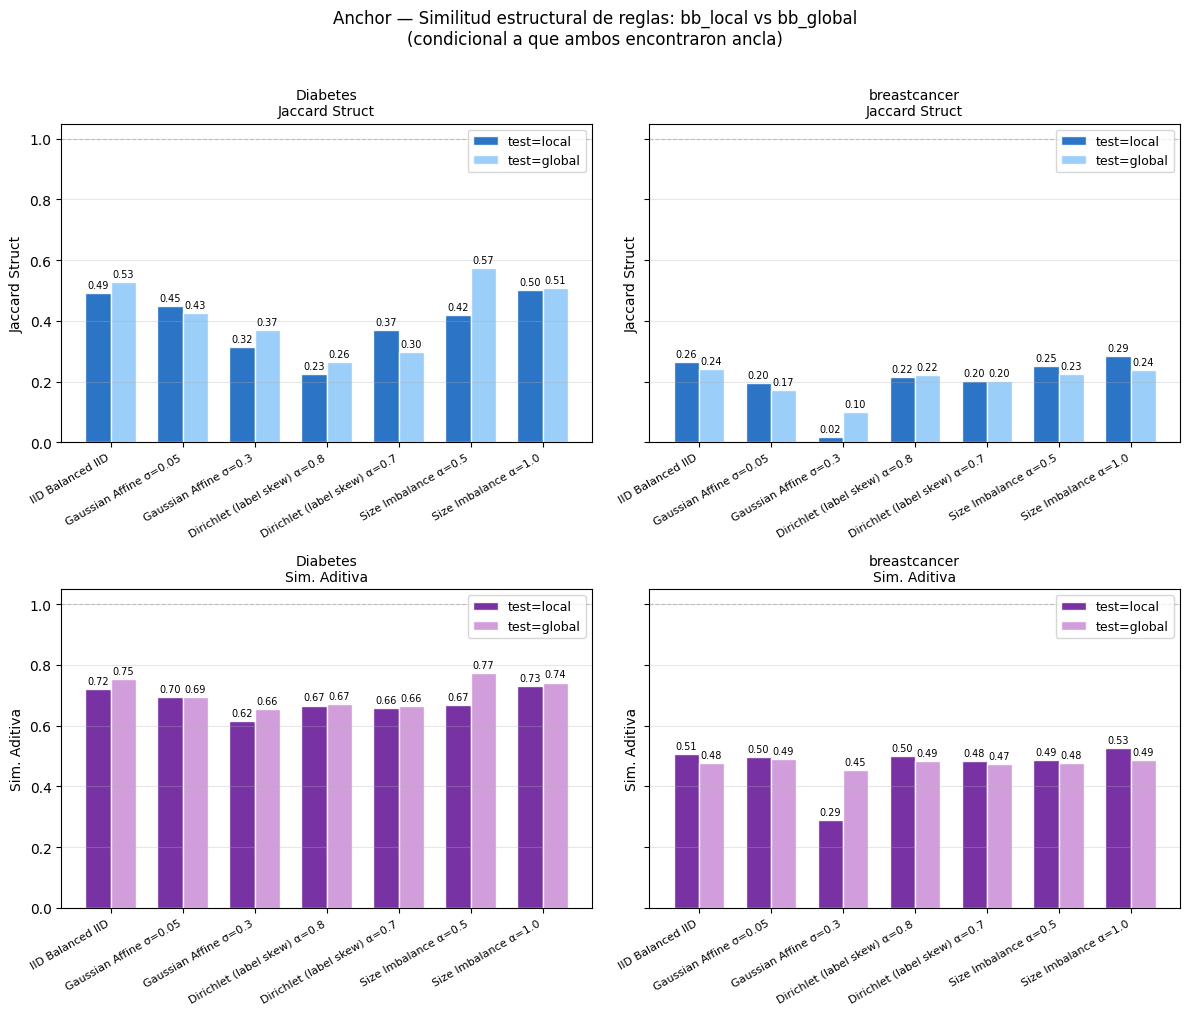

In [20]:

# ===========================================================
# Anchor: similitud estructural entre reglas de bb_local y bb_global
# Métrica: jaccard_anchor_struct_testlocal/testglobal
#          sim_aditiva_anchor_testlocal/testglobal
# Solo sobre pares donde AMBOS modelos encontraron ancla
# ===========================================================

ORDER = [
    'IID Balanced IID',
    'Gaussian Affine σ=0.05',
    'Gaussian Affine σ=0.3',
    'Dirichlet (label skew) α=0.8',
    'Dirichlet (label skew) α=0.7',
    'Size Imbalance α=0.5',
    'Size Imbalance α=1.0',
]

JACC_KEYS = ['jaccard_anchor_struct_testlocal', 'jaccard_anchor_struct_testglobal']
SIM_KEYS  = ['sim_aditiva_anchor_testlocal',    'sim_aditiva_anchor_testglobal']

datasets = sorted(df_all['dataset'].unique())

# ── Tabla ──────────────────────────────────────────────────
print("=" * 72)
print("  Anchor: SIMILITUD ESTRUCTURAL de reglas bb_local vs bb_global")
print("  (media sobre 4/6/8 clientes)")
print("=" * 72)
for dataset in datasets:
    sub   = df_all[df_all['dataset'] == dataset]
    orden = [o for o in ORDER if o in sub['label'].unique()]
    cols  = JACC_KEYS + SIM_KEYS
    tabla = (
        sub.groupby('label')[cols].mean()
           .reindex(orden)
           .rename(columns={
               'jaccard_anchor_struct_testlocal':  'Jacc test=local',
               'jaccard_anchor_struct_testglobal': 'Jacc test=global',
               'sim_aditiva_anchor_testlocal':     'Sim test=local',
               'sim_aditiva_anchor_testglobal':    'Sim test=global',
           })
    )
    tabla['Δ Jacc (G-L)'] = tabla['Jacc test=global'] - tabla['Jacc test=local']
    tabla['Δ Sim  (G-L)'] = tabla['Sim test=global']  - tabla['Sim test=local']
    print(f"\n  {dataset}")
    print(tabla.to_string(float_format='{:.3f}'.format))

# ── Gráfica: grouped bar (2 datasets × 2 métricas) ─────────
fig, axes = plt.subplots(2, len(datasets), figsize=(6 * len(datasets), 10), sharey='row')

ROW_CFG = [
    (JACC_KEYS, ['#1565C0', '#90CAF9'], ['Jacc test=local', 'Jacc test=global'], 'Jaccard Struct'),
    (SIM_KEYS,  ['#6A1B9A', '#CE93D8'], ['Sim test=local',  'Sim test=global'],  'Sim. Aditiva'),
]

for row_idx, (keys, colors, col_names, row_title) in enumerate(ROW_CFG):
    for col_idx, dataset in enumerate(datasets):
        ax  = axes[row_idx, col_idx]
        sub = df_all[df_all['dataset'] == dataset]
        t   = (
            sub.groupby('label')[keys].mean()
               .reindex([o for o in ORDER if o in sub['label'].unique()])
        )
        t.columns = col_names

        x     = np.arange(len(t))
        width = 0.35

        bars_l = ax.bar(x - width/2, t[col_names[0]], width,
                        color=colors[0], alpha=0.9, edgecolor='white', label='test=local')
        bars_g = ax.bar(x + width/2, t[col_names[1]], width,
                        color=colors[1], alpha=0.9, edgecolor='white', label='test=global')

        ax.set_xticks(x)
        ax.set_xticklabels(t.index, rotation=30, ha='right', fontsize=8)
        ax.set_ylim(0.0, 1.05)
        ax.set_title(f'{dataset}\n{row_title}', fontsize=10)
        ax.set_ylabel(row_title)
        ax.axhline(1.0, color='grey', linestyle='--', linewidth=0.8, alpha=0.4)
        ax.grid(axis='y', alpha=0.3)
        ax.legend(fontsize=9, loc='upper right')

        for bar in list(bars_l) + list(bars_g):
            h = bar.get_height()
            if not np.isnan(h):
                ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
                        f'{h:.2f}', ha='center', va='bottom', fontsize=7)

plt.suptitle('Anchor — Similitud estructural de reglas: bb_local vs bb_global\n'
             '(condicional a que ambos encontraron ancla)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()


**Cuando ambos modelos encuentran un ancla, ¿describen la misma región del espacio de decisión?**

- **Jaccard:** ¿usan las mismas features? Si bb_local ancla en "glucosa y BMI" y bb_global ancla en "glucosa y edad", el Jaccard es bajo.
- **Sim. Aditiva:** cuando coinciden en una feature, ¿las condiciones apuntan en el mismo sentido y con rangos similares? Es más permisiva que el Jaccard y siempre da valores más altos.

**El nivel de partida depende del dataset.** En Diabetes el Jaccard es ~0.49 en IID; en BreastCancer es ~0.26. No es un efecto del non-IID — con 30 features, que dos reglas de 2–3 condiciones escojan las mismas es estadísticamente improbable. Este es el techo del método, no de la federación.

**Gaussian σ=0.3 BreastCancer** es el caso más extremo: Jaccard = 0.017 en test local — las reglas de bb_local y bb_global no comparten prácticamente ninguna feature. En test global sube a 0.099, pero sigue siendo muy bajo. La distorsión gaussiana altera tanto el espacio de features que cada modelo ancla en variables completamente distintas.

**Dirichlet α=0.8 Diabetes** muestra la mayor separación entre las dos métricas: Jaccard = 0.226 pero Sim. Aditiva = 0.666. Los modelos divergen en qué feature anclar, pero cuando coinciden en una, las condiciones apuntan en la misma dirección. El label skew afecta a la selección de features, no al sentido de las condiciones.

**Conclusión:** la advertencia principal de Anchor bajo non-IID severo no es que las reglas sean distintas, sino que en muchos casos no hay regla (baja disponibilidad). Gaussian σ=0.3 en BreastCancer es la excepción total: baja disponibilidad y Jaccard ≈ 0 cuando hay regla — el peor escenario posible.

# Conclusión sobre Anchor

Anchor es el explicador más sensible al non-IID de los cuatro. Cuando funciona (heterogeneidad leve), aporta algo que LIME y SHAP no dan: una región estable del espacio donde la predicción es consistente. Cuando falla (Gaussian severo, Dirichlet), no da una explicación peor — directamente no da ninguna.

El hallazgo más relevante es la anomalía de BreastCancer Dirichlet: el bb_global es más explicable que el bb_local en el propio espacio del cliente. Es el único caso donde la federación mejora no solo la precisión sino también la explicabilidad — un argumento directo a favor de adoptar el modelo global.

**Limitaciones:** la disponibilidad baja no es recuperable sin cambiar el método — Anchor no genera regla si no hay región estable. Bajo Gaussian σ=0.3 BreastCancer se da el peor caso: baja disponibilidad y Jaccard ≈ 0 cuando hay regla.

**Mejoras propuestas:**
- **Reducir el umbral de precisión** (de 85% a 70–75%) en escenarios severos — se pierde certeza pero se gana disponibilidad.
- **Fallback automático:** cuando Anchor no encuentra ancla, ofrecer una explicación LIME o SHAP en su lugar en vez de dejar la instancia sin explicación.
- **Pre-selección de features estables** antes de correr Anchor bajo Gaussian — filtrar las features más robustas al ruido del cliente podría mejorar tanto disponibilidad como similitud estructural.

---

# Conclusión general

**Sobre la federación:**

Bajo heterogeneidad leve (IID, Size Imbalance, Gaussian σ=0.05) la federación funciona bien: los modelos convergen, las importancias se alinean, y el bb_global es tan explicable como el bb_local. En Gaussian σ=0.05 el bb_global incluso supera al bb_local en accuracy en el propio test del cliente.

Bajo heterogeneidad severa (Gaussian σ=0.3, Dirichlet) la federación mitiga pero no resuelve: el bb_global mejora algo respecto al bb_local, pero ambos se degradan. En Dirichlet, la accuracy local alta del bb_local es engañosa — el bb_global generaliza mejor en test global.

El hallazgo más relevante: bajo Dirichlet en BreastCancer, el bb_global no solo generaliza mejor sino que también es más explicable que el bb_local (mayor disponibilidad en Anchor). Es un argumento directo a favor de adoptar el modelo federado.

**Sobre la explicabilidad:**

- **LIME y SHAP** son los más robustos — la federación alinea bien las importancias de features incluso bajo non-IID fuerte.
- **LORE** tiene alta fidelidad en todos los escenarios, pero el problema estructural (reglas con features distintas entre bb_local y bb_global) ocurre incluso en IID — no es un problema de la federación sino del método.
- **Anchor** es el más sensible al non-IID: la disponibilidad cae bruscamente bajo heterogeneidad severa. El problema no es que las explicaciones sean malas, sino que directamente no existen.

En ningún caso los explicadores producen explicaciones incorrectas — el riesgo es la ausencia de explicación o la divergencia de features, no la contradicción.

**En una frase:** la federación no rompe la explicabilidad bajo heterogeneidad leve. Bajo heterogeneidad severa, el problema principal no es que las explicaciones sean erróneas sino que pueden no existir (Anchor) o describir el modelo desde perspectivas distintas (LORE, SHAP).